# WaterTracker — Suivi et prévision du remplissage des petits réservoirs par télédétection
### Pipeline complet et reproductible : Google Earth Engine → contrôle qualité → analyse hydrologique → modèle de prévision

**Zone d'étude** : rayon de 50 km autour de Ouagadougou (Burkina Faso), climat soudano-sahélien, une saison des pluies unimodale (juin → octobre).

**Objet** : 65 points d'eau surveillés par l'application WaterTracker (barrages, retenues, mares).

---

#### Questions de recherche
1. **Q1 (hydrologie)** : quelle est la dynamique saisonnière et interannuelle de la surface en eau des réservoirs, et comment répond-elle aux pluies ?
2. **Q2 (télédétection)** : la fusion optique (Sentinel-2) + radar (Sentinel-1) permet-elle d'obtenir une série mensuelle continue malgré la couverture nuageuse de la saison des pluies ?
3. **Q3 (IA)** : peut-on prévoir le **taux de remplissage** de chaque réservoir 1 à 3 mois à l'avance mieux que les références hydrologiques simples (persistance, climatologie) ? Avec quelle incertitude ?
4. **Q4 (opérationnel)** : peut-on émettre une **alerte précoce de niveau critique** fiable ?

#### Plan du notebook
| § | Étape |
|---|---|
| 0 | Configuration et reproductibilité |
| 1 | Zone d'étude et connexion à Earth Engine |
| 2 | Inventaire des réservoirs : contrôle qualité SIG |
| 3 | Extraction satellite et climatique (GEE) |
| 4 | Contrôle qualité et fusion Sentinel-2 / Sentinel-1 |
| 5 | Analyse exploratoire hydrologique |
| 6 | Diagnostic critique de l'approche historique (v2) |
| 7 | Formulation du problème de prévision |
| 8 | Variables explicatives |
| 9 | Protocole de validation |
| 10 | Références (baselines) et modèles |
| 11 | Incertitude, alerte précoce, explicabilité |
| 12 | Généralisation spatiale |
| 13 | Modèle final, sauvegarde, inférence |
| 14 | Limites, perspectives, conclusion |

> Chaque étape commence par les **questions que se posent les quatre experts** : l'hydrologue 💧, le géomaticien (SIG) 🗺️, le programmeur 💻 et l'ingénieur IA 🤖.

---
## 0. Configuration et reproductibilité

💻 *Le notebook doit-il dépendre du backend ?* Oui, partiellement : il réutilise **la même configuration** (`.env` → `app.config`) et **la même base** que l'API, ce qui garantit que le modèle est entraîné sur les mêmes réservoirs que ceux servis par l'application.

🤖 *Comment garantir la reproductibilité ?* Graine aléatoire fixée, versions des bibliothèques journalisées, données GEE **mises en cache** (Parquet) avec une empreinte (hash) enregistrée dans la fiche du modèle.

In [1]:
# Bibliothèques standard
import hashlib
import json
import os
import sys
import time
import warnings
from concurrent.futures import ThreadPoolExecutor
from datetime import date, datetime
from pathlib import Path

In [2]:
# Calcul scientifique
import numpy as np
import pandas as pd
from scipy import stats

In [3]:
# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [4]:
# SIG
import geopandas as gpd
from shapely.geometry import shape, mapping

In [5]:
# Apprentissage automatique
import joblib
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

💻 **Point technique (poste Windows)** : l'antivirus (Avast) intercepte le trafic HTTPS avec son propre certificat racine, que Python ne connaît pas → `SSLCertVerificationError` lors de l'authentification Earth Engine. `truststore` fait utiliser à Python le **magasin de certificats du système**, ce qui résout le problème sans désactiver la vérification TLS (ce qui serait une faille de sécurité).

In [6]:
try:
    import truststore
    truststore.inject_into_ssl()
    print("truststore actif : certificats du système utilisés")
except ImportError:
    print("truststore absent : certificats certifi par défaut")

truststore actif : certificats du système utilisés


In [7]:
# Chemins du projet (le notebook vit dans backend/notebooks/)
BACKEND_DIR = Path.cwd().resolve().parent
if not (BACKEND_DIR / "app").exists():
    raise RuntimeError(f"Lancer le notebook depuis backend/notebooks (cwd={Path.cwd()})")
sys.path.insert(0, str(BACKEND_DIR))

DATA_DIR = BACKEND_DIR / "data" / "gee"
FIG_DIR = BACKEND_DIR / "reports" / "figures"
RUNS_DIR = BACKEND_DIR / "ml" / "runs"
for d in (DATA_DIR, FIG_DIR, RUNS_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(BACKEND_DIR)

D:\Dossiers\WaterTracker_Project\backend


In [8]:
# Paramètres globaux de l'étude
SEED = 42
np.random.seed(SEED)
N_JOBS = 4                    # cœurs pour l'apprentissage (borné : -1 peut bloquer sous Windows si la mémoire est juste)

START_MONTH = "2019-01"       # archive Sentinel-2 L2A complète sur l'Afrique de l'Ouest
FORCE_EXTRACT = False         # True : ré-interroger GEE au lieu du cache
HORIZONS = [1, 2, 3]          # horizons de prévision (mois)
SCALE_M = 10                  # résolution de mesure des surfaces en eau (m)
N_WORKERS = 8                 # requêtes mensuelles simultanées par année
YEARS_IN_PARALLEL = 2         # années extraites en même temps (16 requêtes au total ; quota GEE : 40)

TRAIN_END = "2023-12"         # fin de la période d'entraînement (mois cible)
VALID_END = "2024-12"         # fin de la période de validation (mois cible)

In [9]:
# Style graphique homogène pour les figures de l'article
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})
C_S2, C_S1, C_RAIN, C_MODEL, C_REF = "#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#7f7f7f"
warnings.filterwarnings("ignore", category=FutureWarning)


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")

💻 **Entrées/sorties SIG sans GDAL.** `geopandas.read_file/to_file` s'appuient sur GDAL (pyogrio), dont la DLL entre en conflit sous Windows avec celle de PostgreSQL. Le GeoJSON étant du JSON, on le lit/écrit directement : plus portable et sans dépendance binaire.

In [10]:
def write_geojson(gdf: gpd.GeoDataFrame, path: Path) -> None:
    path.write_text(gdf.to_crs(CRS_WGS84).to_json(drop_id=True, ensure_ascii=False), encoding="utf-8")


def read_geojson(path: Path) -> gpd.GeoDataFrame:
    features = json.loads(path.read_text(encoding="utf-8"))["features"]
    return gpd.GeoDataFrame.from_features(features, crs=CRS_WGS84)

In [11]:
# Journal des versions (à reporter dans la section « Matériel et méthodes »)
import ee
versions = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "geopandas": gpd.__version__,
    "earthengine-api": ee.__version__,
}
pd.Series(versions, name="version").to_frame()

,version
python,3.11.9
numpy,2.4.6
pandas,3.0.2
scikit-learn,1.9.0
geopandas,1.2.0
earthengine-api,1.7.42


---
## 1. Zone d'étude et connexion à Google Earth Engine

🗺️ *Quelle emprise ?* Celle de l'application : un disque de 50 km autour de Ouagadougou (`WATCH_CENTER_*`, `WATCH_RADIUS_M` dans `.env`). On la réutilise pour rester cohérent avec la carte.

🗺️ *Quel système de coordonnées ?* Les géométries sont stockées en **WGS84 (EPSG:4326)**. Pour toute mesure de distance ou de surface on reprojette en **UTM zone 30N (EPSG:32630)**, la projection conforme adaptée à Ouagadougou (≈ -1.5° E). Calculer des surfaces en degrés est une erreur classique.

💻 *Les identifiants ?* Lus depuis `.env` via `app.config.settings`, jamais écrits dans le notebook.

In [12]:
from app.config import settings

CRS_WGS84 = "EPSG:4326"
CRS_UTM = "EPSG:32630"

center_lat, center_lng = settings.watch_center
print(f"Centre : {center_lat:.4f}, {center_lng:.4f} | rayon : {settings.watch_radius_m/1000:.0f} km")
print(f"Projet GEE : {settings.gee_project}")

Centre : 12.3647, -1.5221 | rayon : 50 km
Projet GEE : water-492400


In [13]:
def ee_init(project: str) -> None:
    # Neutralise un éventuel proxy local cassé (127.0.0.1:9) hérité de l'environnement
    for var in ("HTTP_PROXY", "HTTPS_PROXY", "http_proxy", "https_proxy"):
        if ":9" in os.environ.get(var, ""):
            os.environ.pop(var)
    ee.Initialize(project=project)
    # Délai maximal par requête : sans lui, une connexion suspendue bloque le notebook indéfiniment
    ee.data.setDeadline(600_000)


ee_init(settings.gee_project)
print("Earth Engine initialisé :", ee.Number(1).add(1).getInfo() == 2)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine initialisé : True


In [14]:
AOI = ee.Geometry.Point([center_lng, center_lat]).buffer(settings.watch_radius_m)
aoi_gdf = (
    gpd.GeoDataFrame(geometry=[shape(AOI.getInfo())], crs=CRS_WGS84)
)
print(f"Surface de la zone d'étude : {aoi_gdf.to_crs(CRS_UTM).area.iloc[0]/1e6:,.0f} km²")

Surface de la zone d'étude : 7,729 km²


💻 *Les appels GEE peuvent échouer (quota, réseau, `Computation timed out`) ou rester suspendus.* Un délai maximal de 10 min par requête est fixé à l'initialisation ; on encapsule chaque requête dans une fonction avec **reprises exponentielles**, et on récupère les tables directement en `DataFrame` via `ee.data.computeFeatures` (plus robuste que `getInfo()` pour les tables).

In [15]:
def ee_to_df(fc: ee.FeatureCollection, retries: int = 4) -> pd.DataFrame:
    # FeatureCollection GEE -> DataFrame pandas, avec reprises exponentielles
    for attempt in range(retries):
        try:
            df = ee.data.computeFeatures({"expression": fc, "fileFormat": "PANDAS_DATAFRAME"})
            return df.drop(columns=["geo"], errors="ignore")
        except Exception as exc:   # EEException, délai dépassé, coupure réseau
            if attempt == retries - 1:
                raise
            wait = 5 * 2 ** attempt
            print(f"  GEE : {exc} -> nouvelle tentative dans {wait}s")
            time.sleep(wait)

💧 *Quelle période ?* La série doit couvrir plusieurs cycles hydrologiques complets pour séparer la saisonnalité de la variabilité interannuelle. Sentinel-2 L2A est disponible en continu sur la zone depuis début 2019 → **2019-01 jusqu'au dernier mois disponible**.

🤖 *Quel est le « dernier mois disponible » ?* ERA5-Land et CHIRPS sont publiés avec quelques semaines de retard. On le détermine **à partir des données** plutôt qu'en dur, pour que le notebook reste valide quand on le relance.

In [16]:
def last_image_month(collection_id: str) -> str:
    img = ee.ImageCollection(collection_id).sort("system:time_start", False).first()
    return ee.Date(img.get("system:time_start")).format("YYYY-MM").getInfo()


last_era5 = last_image_month("ECMWF/ERA5_LAND/MONTHLY_AGGR")
last_chirps = last_image_month("UCSB-CHG/CHIRPS/DAILY")
last_complete = (pd.Timestamp(date.today()).to_period("M") - 1).strftime("%Y-%m")
END_MONTH = min(last_era5, last_chirps, last_complete)

MONTHS = pd.period_range(START_MONTH, END_MONTH, freq="M")
print(f"ERA5-Land : {last_era5} | CHIRPS : {last_chirps} | dernier mois complet : {last_complete}")
print(f"Période d'étude : {START_MONTH} → {END_MONTH} ({len(MONTHS)} mois)")

ERA5-Land : 2026-09 | CHIRPS : 2026-08 | dernier mois complet : 2026-09
Période d'étude : 2019-01 → 2026-08 (92 mois)


---
## 2. Inventaire des réservoirs : contrôle qualité SIG

Les points d'eau proviennent de la base PostGIS de l'application. Leur géométrie a été remplacée, quand c'était possible, par le **polygone OpenStreetMap** du plan d'eau (`scripts/sync_water_geometries.py`).

🗺️ *Questions du géomaticien avant d'extraire quoi que ce soit :*
- Les géométries sont-elles **valides** (pas d'auto-intersection) ?
- Plusieurs « sources » pointent-elles vers **le même plan d'eau** ? (cela compterait deux fois le même réservoir et créerait une fuite de données entre entraînement et test)
- Les polygones OSM correspondent-ils à la **réalité satellite** ? OSM est cartographié à une date inconnue et parfois approximatif.
- Les sources sans polygone (points) : quelle **zone d'analyse** leur attribuer ?

💧 *Question de l'hydrologue :* un réservoir sahélien n'a pas une emprise fixe : en fin de saison des pluies il **déborde** de son contour cartographié, en fin de saison sèche il se réduit à une mare. La zone d'analyse doit donc **englober l'emprise maximale**, d'où une zone tampon autour du polygone.

In [17]:
from sqlalchemy import text
from app.database import engine

INVENTORY_SNAPSHOT = DATA_DIR / "inventory_snapshot.geojson"

query = text(
    "SELECT id AS source_id, zone_detail, superficie_km2, ST_AsGeoJSON(geometry) AS geojson "
    "FROM water_sources ORDER BY id"
)
try:
    with engine.connect() as conn:
        raw = pd.read_sql(query, conn)
    src = gpd.GeoDataFrame(
        raw.drop(columns="geojson"),
        geometry=[shape(json.loads(g)) for g in raw["geojson"]],
        crs=CRS_WGS84,
    )
    write_geojson(src, INVENTORY_SNAPSHOT)
    print(f"{len(src)} sources lues dans PostGIS (instantané sauvegardé)")
except Exception as exc:
    # Reproductibilité hors-ligne : on repart de l'instantané versionné
    print(f"Base indisponible ({exc.__class__.__name__}) -> instantané local")
    src = read_geojson(INVENTORY_SNAPSHOT)

65 sources lues dans PostGIS (instantané sauvegardé)


In [18]:
src.geom_type.value_counts().rename("nb").to_frame()

,nb
Polygon,62
Point,3


In [19]:
# Validité topologique
invalid = ~src.is_valid
print(f"Géométries invalides : {invalid.sum()}")
src.loc[invalid, "geometry"] = src.loc[invalid, "geometry"].make_valid()

Géométries invalides : 0


🗺️ **Doublons** : on normalise chaque géométrie puis on compare leur représentation binaire (WKB). Deux sources avec exactement le même polygone sont **un seul réservoir**.

In [20]:
src["geom_key"] = src.geometry.normalize().apply(lambda g: hashlib.md5(g.wkb).hexdigest())
dup = src.groupby("geom_key")["source_id"].apply(list)
dup = dup[dup.str.len() > 1]
print(f"{len(dup)} plans d'eau partagés par plusieurs sources :")
for ids in dup:
    print("  sources", ids)

12 plans d'eau partagés par plusieurs sources :
  sources [46, 47]
  sources [61, 62, 63, 64, 65]
  sources [23, 28]
  sources [55, 56, 57]
  sources [37, 39]
  sources [14, 15]
  sources [5, 6, 7, 8]
  sources [24, 27]
  sources [13, 18, 19]
  sources [40, 42, 43]
  sources [44, 45]
  sources [51, 52, 53]


In [21]:
# Un identifiant par réservoir physique ; on garde la liste des sources rattachées
res = (
    src.dissolve(by="geom_key", aggfunc={"source_id": list, "zone_detail": "first"})
    .reset_index()
    .rename(columns={"source_id": "source_ids"})
)
res = res.sort_values("source_ids", key=lambda s: s.str[0]).reset_index(drop=True)
res["reservoir_id"] = [f"R{i:02d}" for i in range(1, len(res) + 1)]
res["osm_area_km2"] = res.to_crs(CRS_UTM).area / 1e6
print(f"{len(src)} sources -> {len(res)} réservoirs physiques")

65 sources -> 44 réservoirs physiques


In [22]:
res["osm_area_km2"].describe(percentiles=[0.1, 0.5, 0.9]).round(3).to_frame().T

,count,mean,std,min,10%,50%,90%,max
osm_area_km2,44.0,1.714,7.96,0.0,0.0,0.406,1.072,53.194


🗺️ **Zones d'analyse** :
- polygone ≥ 5 ha : polygone + **tampon de 100 m** (capte le débordement en hautes eaux, ≈ 5 pixels Sentinel-2) ;
- point ou polygone < 5 ha : **disque de 300 m** autour du centroïde (≈ 28 ha).

Le tampon est calculé en **UTM** (en mètres), jamais en degrés.

In [23]:
MIN_POLY_M2 = 5e4
BUFFER_M = 100
POINT_RADIUS_M = 300
SIMPLIFY_M = 10


def n_vertices(geoms) -> int:
    return int(sum(len(g.exterior.coords) + sum(len(i.coords) for i in g.interiors)
                   for geom in geoms for g in getattr(geom, "geoms", [geom])))


def make_regions(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    utm = gdf.to_crs(CRS_UTM)
    small = utm.area < MIN_POLY_M2
    geom = utm.geometry.buffer(BUFFER_M)
    geom[small] = utm.geometry[small].centroid.buffer(POINT_RADIUS_M)
    # Simplification à 10 m (demi-pixel S2) : les contours JRC vectorisés puis tamponnés
    # comptent des milliers de sommets qui alourdissent inutilement les requêtes GEE.
    geom = geom.simplify(SIMPLIFY_M, preserve_topology=True)
    return gpd.GeoDataFrame(
        {"reservoir_id": gdf["reservoir_id"].values,
         "region_type": np.where(small, "disque 300 m", "polygone + 100 m")},
        geometry=geom.values, crs=CRS_UTM,
    )


regions = make_regions(res)
regions["region_type"].value_counts().to_frame()

,count
region_type,
polygone + 100 m,32
disque 300 m,12


### 2.1 Complétude de l'inventaire

🗺️ *L'inventaire de l'application est-il complet ?* Il a été produit par une détection automatique à 100 m de résolution (`detect_water_sources`, v2). On le confronte à **tous les plans d'eau JRC** de la zone : pixels d'occurrence ≥ 10 % (en eau au moins une année sur dix), vectorisés à 30 m, en ne gardant que les objets ≥ 10 ha.

💧 *Pourquoi c'est important ?* Un système d'alerte qui ignore des réservoirs importants donne une image biaisée de la ressource ; pour le modèle, chaque réservoir supplémentaire est autant de séries d'apprentissage.

In [24]:
JRC_MIN_HA = 10

jrc_water = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence").gte(10).selfMask()
jrc_vec = (
    jrc_water.reduceToVectors(geometry=AOI, scale=30, maxPixels=1e10, tileScale=16,
                              geometryType="polygon", eightConnected=True)
    .map(lambda f: f.set("area_ha", f.geometry().area(10).divide(1e4)))
    .filter(ee.Filter.gte("area_ha", JRC_MIN_HA))
)
jrc_feats = jrc_vec.getInfo()["features"]
jrc_bodies = gpd.GeoDataFrame(
    {"area_ha": [f["properties"]["area_ha"] for f in jrc_feats]},
    geometry=[shape(f["geometry"]) for f in jrc_feats], crs=CRS_WGS84,
)
print(f"Plans d'eau JRC ≥ {JRC_MIN_HA} ha dans la zone : {len(jrc_bodies)} ({jrc_bodies.area_ha.sum():,.0f} ha)")

Plans d'eau JRC ≥ 10 ha dans la zone : 90 (6,589 ha)


In [25]:
hits = gpd.sjoin(jrc_bodies.to_crs(CRS_UTM), regions, predicate="intersects", how="left")
jrc_bodies["covered"] = hits.groupby(level=0)["reservoir_id"].apply(lambda s: s.notna().any())
cov_n = jrc_bodies["covered"].mean()
cov_a = jrc_bodies.loc[jrc_bodies.covered, "area_ha"].sum() / jrc_bodies["area_ha"].sum()
print(f"Couverture de l'inventaire de l'application : {cov_n:.0%} des plans d'eau, {cov_a:.0%} de la surface")
centroids_jrc = jrc_bodies.to_crs(CRS_UTM).centroid.to_crs(CRS_WGS84)
jrc_bodies.assign(lat=centroids_jrc.y, lon=centroids_jrc.x).loc[~jrc_bodies.covered].nlargest(8, "area_ha")[
    ["area_ha", "lat", "lon"]].round(3)

Couverture de l'inventaire de l'application : 38% des plans d'eau, 76% de la surface


,area_ha,lat,lon
82,273.008,12.246,-1.209
83,87.630,12.618,-1.213
85,73.622,12.575,-1.178
44,62.925,12.591,-1.397
12,47.679,12.093,-1.649
24,42.753,12.678,-1.531
64,41.473,12.471,-1.313
14,39.673,12.767,-1.629


🗺️🤖 **Décision : inventaire étendu.** Les grands réservoirs (Ziga, Loumbila, barrages urbains) sont couverts, mais une part importante des plans d'eau moyens manque. On **ajoute** les plans d'eau JRC non couverts à l'étude, avec leur polygone JRC comme géométrie. La colonne `origin` distingue :
- `application` : réservoirs des sources de l'application (prévisions exportées vers l'API) ;
- `JRC` : réservoirs ajoutés (inclus dans l'apprentissage, et proposés pour enrichir la base de l'application).

Les fragments JRC distants de moins de deux tampons sont fusionnés : ils appartiennent au même plan d'eau.

In [26]:
missing = jrc_bodies.loc[~jrc_bodies["covered"]].to_crs(CRS_UTM)
merged = missing.buffer(BUFFER_M).union_all()
parts = list(merged.geoms) if merged.geom_type == "MultiPolygon" else [merged]
clusters = gpd.GeoDataFrame(geometry=parts, crs=CRS_UTM)
missing["cluster"] = gpd.sjoin(missing, clusters, predicate="intersects")["index_right"].groupby(level=0).first()
added = missing.dissolve(by="cluster", aggfunc={"area_ha": "sum"}).reset_index(drop=True)
added["geometry"] = added.geometry.simplify(SIMPLIFY_M, preserve_topology=True)
added = added.to_crs(CRS_WGS84)

added = added.sort_values("area_ha", ascending=False).reset_index(drop=True)
added["reservoir_id"] = [f"J{i:02d}" for i in range(1, len(added) + 1)]
added["source_ids"] = [[] for _ in range(len(added))]
added["zone_detail"] = None
added["origin"] = "JRC"
added["osm_area_km2"] = np.nan
print(f"{len(added)} réservoirs ajoutés depuis JRC ({added.area_ha.sum():,.0f} ha d'occurrence ≥ 10 %)")

56 réservoirs ajoutés depuis JRC (1,584 ha d'occurrence ≥ 10 %)


In [27]:
res["origin"] = "application"
res = gpd.GeoDataFrame(
    pd.concat([res, added[["reservoir_id", "source_ids", "zone_detail", "origin", "osm_area_km2", "geometry"]]],
              ignore_index=True),
    geometry="geometry", crs=CRS_WGS84,
)
regions = make_regions(res)
res["region_type"] = regions["region_type"].values
res["region_km2"] = regions.area.values / 1e6
print(f"Sommets envoyés à GEE : {n_vertices(regions.geometry):,}")
res.groupby("origin").agg(n=("reservoir_id", "size"), zones_km2=("region_km2", "sum")).round(2)

Sommets envoyés à GEE : 4,919


,n,zones_km2
origin,,
JRC,56,34.23
application,44,112.65


🤖 *Risque :* deux zones tampons qui se chevauchent compteraient deux fois les mêmes pixels. On le contrôle.

In [28]:
# Chevauchement entre zones d'analyse
pairs = gpd.sjoin(regions, regions, predicate="intersects")
pairs = pairs[pairs["reservoir_id_left"] < pairs["reservoir_id_right"]]
overlaps = []
for _, p in pairs.iterrows():
    a = regions.loc[regions.reservoir_id == p.reservoir_id_left].geometry.iloc[0]
    b = regions.loc[regions.reservoir_id == p.reservoir_id_right].geometry.iloc[0]
    inter = a.intersection(b).area
    overlaps.append((p.reservoir_id_left, p.reservoir_id_right, inter / 1e4, inter / min(a.area, b.area)))
overlaps = pd.DataFrame(overlaps, columns=["r1", "r2", "inter_ha", "frac_plus_petite"])
overlaps.sort_values("frac_plus_petite", ascending=False).head(10).round(3)

,r1,r2,inter_ha,frac_plus_petite


🗺️ *Comment traiter les chevauchements ?* Si une zone est presque entièrement incluse dans une autre (> 50 %), il s'agit en pratique du **même plan d'eau** cartographié deux fois sous des formes différentes : on le signale (`overlap_flag`) pour l'exclure des analyses de généralisation. Les petits recouvrements de bordure (quelques hectares de tampon) sont négligeables.

In [29]:
big = overlaps[overlaps["frac_plus_petite"] > 0.5]
flagged = set(big["r1"]) | set(big["r2"])
res["overlap_flag"] = res["reservoir_id"].isin(flagged)
print(f"Réservoirs avec chevauchement majeur : {sorted(flagged) or 'aucun'}")

Réservoirs avec chevauchement majeur : aucun


🗺️ **Confrontation OSM ↔ satellite.** La couche **JRC Global Surface Water** (Pekel et al., 2016, *Nature*) fournit, à 30 m, la fréquence d'occurrence de l'eau sur 1984-2021 et son extension maximale. Pour chaque zone d'analyse on calcule :
- `jrc_max_km2` : surface ayant été en eau au moins une fois (emprise maximale historique) ;
- `jrc_occ_mean` : occurrence moyenne de l'eau (%) sur cette emprise → **permanence** du plan d'eau ;
- `jrc_seasonality` : nombre moyen de mois en eau par an.

On récupère aussi des variables **statiques** utiles au modèle : altitude et pente (SRTM 30 m).

In [30]:
def to_ee_fc(gdf: gpd.GeoDataFrame, id_col: str) -> ee.FeatureCollection:
    # GeoDataFrame -> FeatureCollection GEE (en WGS84)
    g = gdf.to_crs(CRS_WGS84)
    return ee.FeatureCollection([
        ee.Feature(ee.Geometry(mapping(geom)), {id_col: rid})
        for rid, geom in zip(g[id_col], g.geometry)
    ])


regions_fc = to_ee_fc(regions, "reservoir_id")
# Rectangle englobant : suffit pour sélectionner les scènes, sans recalculer l'union des polygones
REGIONS_BBOX = ee.Geometry.Rectangle(list(regions.to_crs(CRS_WGS84).total_bounds))
print(regions_fc.size().getInfo(), "zones envoyées à GEE")

100 zones envoyées à GEE


In [31]:
gsw = ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
srtm = ee.Image("USGS/SRTMGL1_003")
pa = ee.Image.pixelArea()

max_ext = gsw.select("max_extent")
static_img = ee.Image.cat([
    max_ext.multiply(pa).rename("jrc_max_m2"),
    gsw.select("occurrence").updateMask(max_ext).rename("jrc_occ_mean"),
    gsw.select("seasonality").updateMask(max_ext).rename("jrc_seasonality"),
    srtm.rename("elev_m"),
    ee.Terrain.slope(srtm).rename("slope_deg"),
])

💻 On a besoin d'une **somme** (surface d'emprise maximale) et de **moyennes** (occurrence, altitude, pente) : deux `reduceRegions` séparés, joints en pandas, restent plus lisibles qu'un réducteur combiné.

In [32]:
static_sum = ee_to_df(
    max_ext.multiply(pa).rename("jrc_max_m2")
    .reduceRegions(collection=regions_fc, reducer=ee.Reducer.sum(), scale=30)
)
static_mean = ee_to_df(
    static_img.select(["jrc_occ_mean", "jrc_seasonality", "elev_m", "slope_deg"])
    .reduceRegions(collection=regions_fc, reducer=ee.Reducer.mean(), scale=30)
)
static = static_sum.rename(columns={"sum": "jrc_max_m2"}).merge(static_mean, on="reservoir_id")
static["jrc_max_km2"] = static.pop("jrc_max_m2") / 1e6
res = res.merge(static, on="reservoir_id", how="left")
res[["reservoir_id", "osm_area_km2", "jrc_max_km2", "jrc_occ_mean", "jrc_seasonality", "elev_m"]].head()

,reservoir_id,osm_area_km2,jrc_max_km2,jrc_occ_mean,jrc_seasonality,elev_m
0,R01,53.194081,64.127997,73.837706,9.733854,266.056466
1,R02,0.769947,0.572947,37.169207,4.169118,276.131223
2,R03,0.281011,0.221927,36.385827,3.958333,283.417802
3,R04,0.623673,0.804822,58.582298,4.915261,284.132312
4,R05,1.603053,1.815138,63.622323,7.591635,271.271736


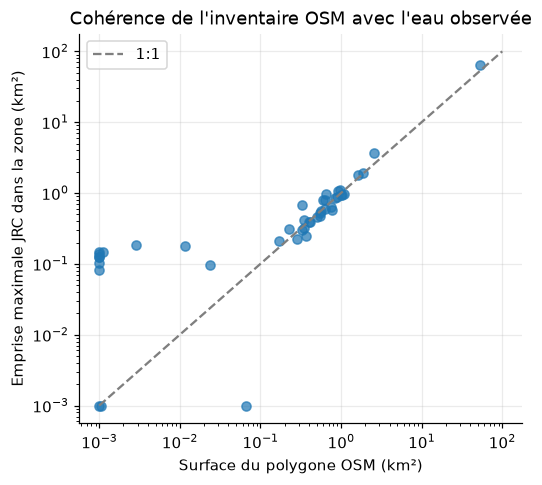

In [33]:
fig, ax = plt.subplots(figsize=(5.2, 4.6))
app = res[res["origin"] == "application"]
ax.loglog(app["osm_area_km2"].clip(lower=1e-3), app["jrc_max_km2"].clip(lower=1e-3), "o", alpha=0.7)
lims = [1e-3, 100]
ax.plot(lims, lims, "--", color=C_REF, label="1:1")
ax.set_xlabel("Surface du polygone OSM (km²)")
ax.set_ylabel("Emprise maximale JRC dans la zone (km²)")
ax.set_title("Cohérence de l'inventaire OSM avec l'eau observée")
ax.legend()
savefig(fig, "fig02_osm_vs_jrc")
plt.show()

🗺️ *Que faire des réservoirs que JRC n'a jamais vus en eau ?* Si `jrc_max_km2` ≈ 0, le polygone/point ne correspond à **aucun plan d'eau détectable à 30 m** : mare temporaire minuscule, erreur de géolocalisation ou objet mal étiqueté dans OSM. On les marque `jrc_absent` ; ils resteront dans l'extraction (Sentinel-2 est plus fin, à 10-20 m), mais une série qui reste nulle sera exclue de la modélisation (§4).

In [34]:
res["jrc_absent"] = res["jrc_max_km2"] < 0.01   # < 1 ha d'eau jamais observée
print(f"Réservoirs sans eau JRC détectable : {res['jrc_absent'].sum()}")
res.loc[res["jrc_absent"], ["reservoir_id", "origin", "source_ids", "osm_area_km2", "region_type"]]

Réservoirs sans eau JRC détectable : 3


,reservoir_id,origin,source_ids,osm_area_km2,region_type
15,R16,application,[22],0.066352,polygone + 100 m
18,R19,application,[25],0.001050,disque 300 m
26,R27,application,[35],0.000251,disque 300 m


💧 **Bassin versant.** La pluie qui remplit un réservoir tombe sur son **bassin versant**, pas sur le plan d'eau. Plutôt qu'un tampon arbitraire, on utilise **HydroBASINS niveau 10** (Lehner & Grill, 2013) : on associe à chaque réservoir le sous-bassin qui contient son centroïde. Les variables climatiques seront moyennées sur ce sous-bassin.

🗺️ *Limite assumée :* le sous-bassin de niveau 10 (≈ 100-400 km²) n'est pas exactement le bassin d'alimentation du barrage (il faudrait le délimiter à partir de l'exutoire sur un MNT). C'est une approximation standard à cette échelle, cohérente avec la résolution de CHIRPS (≈ 5,5 km).

In [35]:
basins_all = ee.FeatureCollection("WWF/HydroSHEDS/v1/Basins/hybas_10")
centroids = res.to_crs(CRS_UTM).geometry.centroid.to_crs(CRS_WGS84)
pts_fc = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([p.x, p.y]), {"reservoir_id": rid})
    for rid, p in zip(res["reservoir_id"], centroids)
])
joined = ee.Join.saveFirst("basin").apply(
    pts_fc, basins_all, ee.Filter.intersects(leftField=".geo", rightField=".geo")
)
link = ee_to_df(joined.map(lambda f: ee.Feature(None, {
    "reservoir_id": f.get("reservoir_id"),
    "hybas_id": ee.Feature(f.get("basin")).get("HYBAS_ID"),
    "basin_km2": ee.Feature(f.get("basin")).get("SUB_AREA"),
    "upstream_km2": ee.Feature(f.get("basin")).get("UP_AREA"),
})))
res = res.merge(link, on="reservoir_id", how="left")
print(f"{res['hybas_id'].nunique()} sous-bassins distincts pour {len(res)} réservoirs")

42 sous-bassins distincts pour 100 réservoirs


In [36]:
# Géométries des sous-bassins récupérées une seule fois (évite un filtrage spatial global à chaque mois)
basin_ids = sorted(res["hybas_id"].dropna().astype(int).unique().tolist())
basins_geo = basins_all.filter(ee.Filter.inList("HYBAS_ID", basin_ids)).getInfo()["features"]
basins = gpd.GeoDataFrame(
    {"hybas_id": [f["properties"]["HYBAS_ID"] for f in basins_geo]},
    geometry=[shape(f["geometry"]) for f in basins_geo],
    crs=CRS_WGS84,
)
basins_fc = to_ee_fc(basins, "hybas_id")

🗺️ **Carte de la zone d'étude.** Fond : composite Sentinel-2 en couleurs naturelles de fin de saison des pluies (octobre 2024), téléchargé depuis GEE comme vignette géoréférencée.

In [37]:
import io
import urllib.request

bounds = aoi_gdf.total_bounds  # xmin, ymin, xmax, ymax
bbox = ee.Geometry.Rectangle(list(bounds))
rgb = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(bbox).filterDate("2024-10-01", "2024-11-15")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
    .median().select(["B4", "B3", "B2"])
)
def fetch_background(image: ee.Image, retries: int = 3):
    # Le fond de carte est décoratif : en cas d'échec réseau, on continue sans lui
    for attempt in range(retries):
        try:
            url = image.getThumbURL({"region": bbox, "dimensions": 1024, "min": 300, "max": 2500, "format": "png"})
            with urllib.request.urlopen(url, timeout=180) as r:
                return plt.imread(io.BytesIO(r.read()), format="png")
        except Exception as exc:
            print(f"  fond de carte : tentative {attempt + 1} échouée ({exc.__class__.__name__})")
    return None


def draw_background(ax, alpha: float = 1.0) -> None:
    if background is not None:
        ax.imshow(background, extent=[bounds[0], bounds[2], bounds[1], bounds[3]], alpha=alpha)
    else:
        ax.set_facecolor("#e8e4d8")
    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])


background = fetch_background(rgb)
print("Fond de carte :", "indisponible" if background is None else background.shape)

Fond de carte : (1007, 1024, 3)


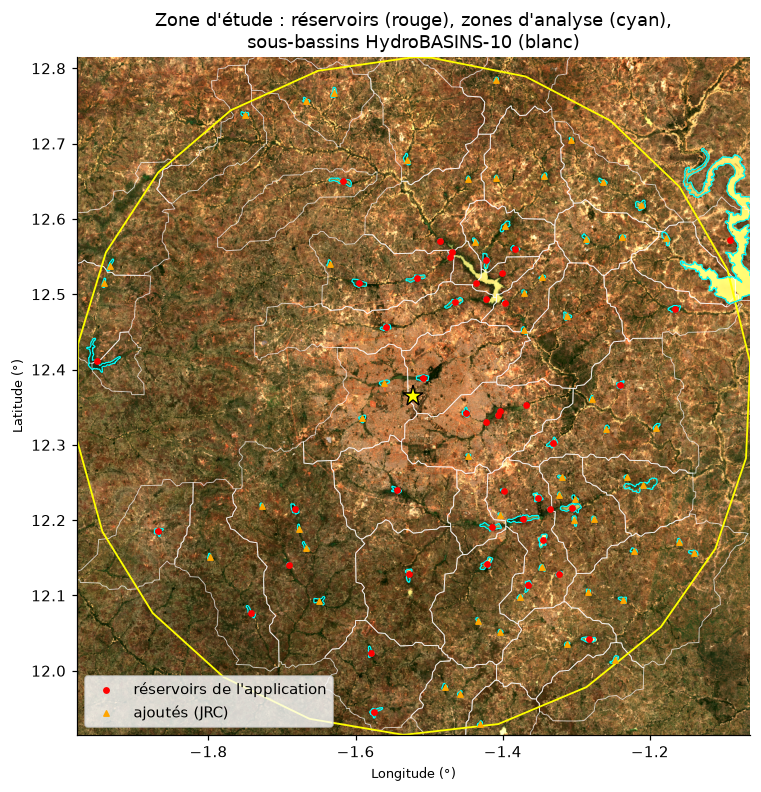

In [38]:
fig, ax = plt.subplots(figsize=(8, 8))
draw_background(ax)
basins.boundary.plot(ax=ax, color="white", lw=0.6, alpha=0.7)
aoi_gdf.boundary.plot(ax=ax, color="yellow", lw=1.2)
regions.to_crs(CRS_WGS84).boundary.plot(ax=ax, color="cyan", lw=0.8)
c = res.to_crs(CRS_UTM).geometry.centroid.to_crs(CRS_WGS84)
is_app = (res["origin"] == "application").values
ax.scatter(c.x[is_app], c.y[is_app], s=12, c="red", zorder=3, label="réservoirs de l'application")
ax.scatter(c.x[~is_app], c.y[~is_app], s=12, c="orange", marker="^", zorder=3, label="ajoutés (JRC)")
ax.legend(loc="lower left")
ax.plot(center_lng, center_lat, marker="*", color="yellow", ms=14, mec="k")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("Zone d'étude : réservoirs (rouge), zones d'analyse (cyan),\nsous-bassins HydroBASINS-10 (blanc)")
ax.grid(False)
savefig(fig, "fig01_study_area")
plt.show()

---
## 3. Extraction satellite et climatique (Google Earth Engine)

### 3.1 Choix méthodologiques

💧 *Quelle variable hydrologique ?* La v2 mesurait le **NDWI en un seul point** (le centroïde) sur des composites **semestriels**. Or :
- la grandeur hydrologiquement pertinente est la **surface en eau** du réservoir (proxy de son stock via la relation hauteur-surface-volume) ;
- un point au centre reste en eau jusqu'à l'assèchement presque complet → il ne voit pas la décrue ;
- un pas semestriel (janv.-juin / juil.-déc.) mélange le pic de saison sèche (avril-mai) avec la fin des pluies : il est **inadapté au calendrier hydrologique sahélien**.

→ On mesure la **surface en eau mensuelle** dans chaque zone d'analyse.

🛰️ *Quel indice d'eau ?* Le **MNDWI** (Xu, 2006) = (Vert − SWIR1)/(Vert + SWIR1) (B3, B11) discrimine mieux l'eau du bâti et des sols nus que le NDWI de McFeeters (B3, B8) utilisé en v2, en particulier pour les **eaux turbides** typiques du Sahel. Seuil : MNDWI > 0 (valeur physique standard), avec une **analyse de sensibilité** à ±0,1.

📐 *Quelle résolution ?* **10 m**, la meilleure résolution de Sentinel-2. Mais attention aux résolutions natives :

| Donnée | Résolution native | Usage ici |
|---|---|---|
| Sentinel-2 B3 (vert), B4, B8 (PIR) | **10 m** | NDWI, NDVI |
| Sentinel-2 B11 (SWIR1) | 20 m | MNDWI après **affinage à 10 m** |
| Sentinel-1 GRD (VV) | pixel de 10 m (résolution réelle ≈ 20 × 22 m) | comblement des mois nuageux |
| JRC Global Surface Water | 30 m (Landsat) | *repérage* des plans d'eau uniquement, jamais la mesure |
| CHIRPS / ERA5-Land | ≈ 5,5 km / 11 km | forçages climatiques du bassin |

Pour obtenir un MNDWI à 10 m, on applique la méthode de **Du et al. (2016)** : la bande SWIR est rééchantillonnée à 10 m (interpolation bilinéaire, appliquée image par image dans sa projection d'origine) avant le calcul de l'indice ; le détail spatial est porté par la bande verte, nativement à 10 m. On calcule en parallèle la surface par **NDWI (B3/B8), entièrement native à 10 m**, comme contrôle indépendant de l'affinage. Toutes les surfaces sont mesurées avec `scale = 10`.

☁️ *Et les nuages ?* La v2 filtrait des **scènes entières** (`CLOUDY_PIXEL_PERCENTAGE < 20`), ce qui supprime presque toutes les images de juillet-septembre. On masque plutôt **pixel par pixel** avec **Cloud Score+** (Pasquarella et al., 2023), seuil `cs_cdf ≥ 0,60` recommandé par Google, puis on fait une médiane mensuelle. On mesure la **fraction de pixels valides** de chaque zone et de chaque mois pour le contrôle qualité.

📡 *Et si un mois reste nuageux ?* **Sentinel-1** (radar en bande C) voit à travers les nuages : l'eau libre, surface lisse, renvoie très peu de signal (rétrodiffusion VV faible). On l'extrait en parallèle pour **combler les trous** optiques (§4).

🌧️ *Quels forçages ?* Pluie **CHIRPS** (journalière, 0,05°), et **ERA5-Land** mensuel : température à 2 m, évaporation potentielle et réelle, humidité du sol superficielle. Moyennés sur le sous-bassin HydroBASINS.

💻 *Comment extraire efficacement ?* Tout le calcul reste **côté serveur** : on construit une image mensuelle, on la réduit sur les zones (`reduceRegions`), on aplatit une année entière en une seule requête. Le résultat est mis en **cache Parquet par année** : relancer le notebook ne réinterroge GEE que si `FORCE_EXTRACT = True` ou si un mois manque.

In [39]:
S2_COL = "COPERNICUS/S2_SR_HARMONIZED"
CS_COL = "GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED"
CS_THRESHOLD = 0.60
MNDWI_THRESHOLDS = {"water_m2": 0.0, "water_lo_m2": -0.1, "water_hi_m2": 0.1}


def mask_and_sharpen(im: ee.Image) -> ee.Image:
    # Masque nuages (Cloud Score+) puis affinage de B11 (20 m) sur la grille 10 m
    im = im.updateMask(im.select("cs_cdf").gte(CS_THRESHOLD))
    return im.addBands(im.select("B11").resample("bilinear"), overwrite=True)

In [40]:
def s2_monthly_image(start: ee.Date) -> ee.Image:
    # Composite mensuel Sentinel-2 masqué Cloud Score+ -> bandes de surface (m²)
    end = start.advance(1, "month")
    col = (
        ee.ImageCollection(S2_COL)
        .filterBounds(REGIONS_BBOX)
        .filterDate(start, end)
        .linkCollection(ee.ImageCollection(CS_COL), ["cs_cdf"])
        .map(mask_and_sharpen)
    )
    comp = col.median()
    mndwi = comp.normalizedDifference(["B3", "B11"]).rename("mndwi")
    ndwi = comp.normalizedDifference(["B3", "B8"]).rename("ndwi")
    ndvi = comp.normalizedDifference(["B8", "B4"]).rename("ndvi")

    area_bands = [
        mndwi.gt(thr).unmask(0).multiply(pa).rename(name)
        for name, thr in MNDWI_THRESHOLDS.items()
    ]
    # Contrôle indépendant : surface par NDWI, dont les deux bandes sont natives à 10 m
    area_bands.append(ndwi.gt(0).unmask(0).multiply(pa).rename("water_ndwi_m2"))
    valid = mndwi.mask().unmask(0).multiply(pa).rename("valid_m2")
    region = pa.rename("region_m2")
    return ee.Image.cat(area_bands + [valid, region]), ee.Image.cat([mndwi, ndwi, ndvi]), col.size()

💻 Deux réductions par mois : une **somme** des surfaces (m²) et une **moyenne** des indices (MNDWI, NDWI, NDVI) sur la zone. La moyenne du NDWI servira à comparer avec la v2.

📐 *Échelle de réduction :* `SCALE_M` = 10 m. La fonction accepte l'échelle en paramètre pour pouvoir **quantifier l'effet de la résolution** (comparaison 10 m / 20 m en §4.6).

In [41]:
def s2_month_features(month_str: ee.String, scale: int = SCALE_M) -> ee.FeatureCollection:
    start = ee.Date.parse("YYYY-MM", month_str)
    areas, indices, n_img = s2_monthly_image(start)
    sums = areas.reduceRegions(collection=regions_fc, reducer=ee.Reducer.sum(), scale=scale, tileScale=4)
    means = indices.reduceRegions(collection=sums, reducer=ee.Reducer.mean(), scale=scale, tileScale=4)
    return means.map(lambda f: f.set({"month": month_str, "n_s2": n_img}).setGeometry(None))

📡 **Sentinel-1.** Médiane mensuelle de la rétrodiffusion VV (dB, mode IW, orbite ascendante, la seule acquise sur la zone). Le seuil de détection de l'eau n'est pas universel (rugosité due au vent, sols sableux secs très peu rétrodiffusants) : on extrait la surface pour **plusieurs seuils** et on **calibrera** le meilleur sur les mois où Sentinel-2 est fiable (§4). La médiane temporelle de ~5-6 acquisitions réduit déjà le chatoiement (*speckle*).

In [42]:
S1_THRESHOLDS_DB = [-14, -16, -18, -20]


def s1_month_features(month_str: ee.String) -> ee.FeatureCollection:
    start = ee.Date.parse("YYYY-MM", month_str)
    col = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(REGIONS_BBOX)
        .filterDate(start, start.advance(1, "month"))
        .filter(ee.Filter.eq("instrumentMode", "IW"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .select("VV")
    )
    vv = col.median()
    bands = [vv.lt(t).unmask(0).multiply(pa).rename(f"s1_water_{abs(t)}_m2") for t in S1_THRESHOLDS_DB]
    bands.append(vv.mask().unmask(0).multiply(pa).rename("s1_valid_m2"))
    sums = ee.Image.cat(bands).reduceRegions(collection=regions_fc, reducer=ee.Reducer.sum(), scale=SCALE_M, tileScale=4)
    return sums.map(lambda f: f.set({"month": month_str, "n_s1": col.size()}).setGeometry(None))

In [43]:
ERA5_BANDS = {
    "temperature_2m": "t2m_k",
    "potential_evaporation_sum": "pet_m",
    "total_evaporation_sum": "aet_m",
    "volumetric_soil_water_layer_1": "soil_moist",
}


def climate_month_features(month_str: ee.String) -> ee.FeatureCollection:
    start = ee.Date.parse("YYYY-MM", month_str)
    end = start.advance(1, "month")
    precip = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").filterDate(start, end).sum().rename("precip_mm")
    era5 = (
        ee.Image(ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR").filterDate(start, end).first())
        .select(list(ERA5_BANDS), list(ERA5_BANDS.values()))
    )
    stats_fc = precip.addBands(era5).reduceRegions(collection=basins_fc, reducer=ee.Reducer.mean(), scale=5000)
    return stats_fc.map(lambda f: f.set("month", month_str).setGeometry(None))

💻 **Cache par année, requêtes par mois, en parallèle.** Une requête = 1 mois × tous les réservoirs. À 10 m, un mois de Sentinel-2 demande 2 à 5 min de calcul côté serveur (≈ 50 images, 1,5 million de pixels) : en séquentiel, l'archive complète prendrait plus de 3 h. Les mois étant indépendants, on lance `N_WORKERS` requêtes simultanées par année, sur `YEARS_IN_PARALLEL` années à la fois (le calcul a lieu chez Google ; le poste local ne fait qu'attendre). Si une requête reste suspendue, le délai maximal l'interrompt et seule celle-ci est rejouée. Le fichier `<produit>_<tag>_<année>.parquet` n'est recalculé que s'il manque des mois ou des entités, ou si `FORCE_EXTRACT`.

In [44]:
def fetch_year(name: str, month_fn, wanted: list, path: Path) -> pd.DataFrame:
    # Extrait les mois d'une année en parallèle et écrit le fichier de cache
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        parts = list(pool.map(lambda m: ee_to_df(month_fn(ee.String(m))), wanted))
    df = pd.concat(parts, ignore_index=True)
    df.to_parquet(path, index=False)
    msg = f"{datetime.now():%H:%M:%S} {path.stem} : {len(df)} lignes en {time.time() - t0:.0f}s"
    print("  " + msg)
    with open(DATA_DIR / "extract.log", "a", encoding="utf-8") as log:
        print(msg, file=log)
    return df

In [45]:
def extract_by_year(name: str, month_fn, months: pd.PeriodIndex, key_col: str, keys, tag: str = "") -> pd.DataFrame:
    # Le cache n'est réutilisé que s'il contient tous les mois ET toutes les entités demandées
    keys = set(keys)
    frames, todo = {}, {}
    for year in sorted(set(months.year)):
        wanted = [m.strftime("%Y-%m") for m in months if m.year == year]
        path = DATA_DIR / f"{name}{tag}_{year}.parquet"
        if path.exists() and not FORCE_EXTRACT:
            cached = pd.read_parquet(path)
            if set(wanted) <= set(cached["month"]) and keys <= set(cached[key_col]):
                frames[year] = cached
                continue
        todo[year] = (wanted, path)
    # Années manquantes : YEARS_IN_PARALLEL à la fois, chacune avec N_WORKERS requêtes mensuelles
    with ThreadPoolExecutor(max_workers=YEARS_IN_PARALLEL) as pool:
        futures = {y: pool.submit(fetch_year, name, month_fn, w, p) for y, (w, p) in todo.items()}
        frames.update({y: f.result() for y, f in futures.items()})
    out = pd.concat([frames[y] for y in sorted(frames)], ignore_index=True)
    return out[out["month"].isin(months.strftime("%Y-%m")) & out[key_col].isin(keys)]

In [46]:
t0 = time.time()
s2_raw = extract_by_year("s2", s2_month_features, MONTHS, "reservoir_id", res["reservoir_id"], tag=f"_{SCALE_M}m")
print(f"Sentinel-2 : {s2_raw.shape} en {time.time() - t0:.0f}s")

Sentinel-2 : (9200, 12) en 8s


In [47]:
t0 = time.time()
s1_raw = extract_by_year("s1", s1_month_features, MONTHS, "reservoir_id", res["reservoir_id"], tag=f"_{SCALE_M}m")
print(f"Sentinel-1 : {s1_raw.shape} en {time.time() - t0:.0f}s")

Sentinel-1 : (9200, 8) en 0s


In [48]:
t0 = time.time()
clim_raw = extract_by_year("climate", climate_month_features, MONTHS, "hybas_id", basin_ids)
print(f"Climat : {clim_raw.shape} en {time.time() - t0:.0f}s")

Climat : (3864, 7) en 0s


In [49]:
s2_raw.head()

,mndwi,month,n_s2,ndvi,ndwi,region_m2,reservoir_id,valid_m2,water_hi_m2,water_lo_m2,water_m2,water_ndwi_m2
0,0.542658,2019-01,54,-0.356318,0.309473,6.928101e+07,R01,6.928101e+07,5.536836e+07,5.668158e+07,5.598163e+07,5.565915e+07
1,-0.105849,2019-01,54,0.066536,-0.136915,1.244528e+06,R02,1.244528e+06,4.117574e+05,4.574651e+05,4.341745e+05,4.028293e+05
2,-0.363334,2019-01,54,0.195297,-0.267967,6.745823e+05,R03,6.745823e+05,9.688710e+04,1.158179e+05,1.079543e+05,1.097018e+05
3,0.163617,2019-01,54,-0.081141,0.024586,1.138182e+06,R04,1.138182e+06,6.061988e+05,6.448850e+05,6.256391e+05,5.908176e+05
4,0.225239,2019-01,54,-0.137623,0.181200,2.448286e+06,R05,2.448286e+06,1.608399e+06,1.679116e+06,1.644340e+06,1.632814e+06


In [50]:
# Sauvegarde de l'inventaire enrichi (attributs SIG + statiques)
res_out = res.drop(columns=["geom_key"]).copy()
res_out["source_ids"] = res_out["source_ids"].apply(lambda l: ",".join(map(str, l)))
write_geojson(res_out, DATA_DIR / "reservoirs.geojson")
write_geojson(regions, DATA_DIR / "analysis_regions.geojson")
print("Inventaire et zones d'analyse sauvegardés")

Inventaire et zones d'analyse sauvegardés

---
## 4. Contrôle qualité et fusion Sentinel-2 / Sentinel-1

### 4.1 Mise en forme

💻 Une ligne = un réservoir × un mois. On convertit tout en unités lisibles (ha, mm, °C) et on calcule la **fraction de pixels valides** (non nuageux) de chaque observation optique.

In [51]:
s2 = s2_raw.copy()
s2["valid_frac"] = s2["valid_m2"] / s2["region_m2"]
area_cols = ["water_m2", "water_lo_m2", "water_hi_m2", "water_ndwi_m2"]
for col in area_cols:
    s2[col.replace("_m2", "_ha")] = s2[col] / 1e4
s2 = s2.drop(columns=area_cols + ["valid_m2"])
s2["region_ha"] = s2.pop("region_m2") / 1e4
s2.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
mndwi,9195.0,-0.219,0.215,-0.589,-0.402,-0.265,-0.063,0.704
n_s2,9200.0,53.804,9.686,41.000,48.000,49.500,54.000,82.000
ndvi,9195.0,0.177,0.118,-0.391,0.120,0.165,0.235,0.665
ndwi,9195.0,-0.242,0.117,-0.601,-0.313,-0.256,-0.185,0.370
valid_frac,9200.0,0.994,0.057,0.000,1.000,1.000,1.000,1.000
water_ha,9200.0,72.285,522.626,0.000,0.505,9.766,27.312,6740.099
water_lo_ha,9200.0,75.749,531.859,0.000,1.390,11.833,30.382,6777.923
water_hi_ha,9200.0,68.600,512.230,0.000,0.000,7.539,23.945,6695.413
water_ndwi_ha,9200.0,57.874,448.146,0.000,0.000,4.797,19.082,6387.794
region_ha,9200.0,146.855,685.416,27.551,34.729,54.286,93.418,6928.101


In [52]:
s1 = s1_raw.copy()
for t in S1_THRESHOLDS_DB:
    s1[f"s1_water_{abs(t)}_ha"] = s1.pop(f"s1_water_{abs(t)}_m2") / 1e4
s1["s1_valid_ha"] = s1.pop("s1_valid_m2") / 1e4
s1[["n_s1"]].describe().T

,count,mean,std,min,25%,50%,75%,max
n_s1,9200.0,6.836957,1.855042,2.0,6.0,7.0,8.0,11.0


In [53]:
clim = clim_raw.copy()
clim["t2m_c"] = clim.pop("t2m_k") - 273.15
# ERA5 : évaporations en mètres d'eau, négatives quand l'eau quitte la surface -> mm positifs
clim["pet_mm"] = -clim.pop("pet_m") * 1000
clim["aet_mm"] = -clim.pop("aet_m") * 1000
clim["hybas_id"] = clim["hybas_id"].astype("int64")
clim.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
hybas_id,3864.0,1.100924e+09,445618.10,1.100711e+09,1.100719e+09,1.100726e+09,1.100738e+09,1.101927e+09
precip_mm,3864.0,6.931000e+01,86.13,0.000000e+00,2.800000e-01,2.369000e+01,1.136500e+02,3.556100e+02
soil_moist,3864.0,1.800000e-01,0.09,5.000000e-02,1.200000e-01,1.500000e-01,2.500000e-01,4.600000e-01
t2m_c,3864.0,2.907000e+01,2.68,2.403000e+01,2.693000e+01,2.826000e+01,3.154000e+01,3.522000e+01
pet_mm,3864.0,3.424400e+02,87.08,1.625000e+02,2.664100e+02,3.652700e+02,4.143000e+02,5.067300e+02
aet_mm,3864.0,4.574000e+01,35.61,4.580000e+00,1.597000e+01,2.833000e+01,7.973000e+01,1.313200e+02


In [54]:
panel = (
    s2.merge(s1, on=["reservoir_id", "month"], how="left")
    .merge(res[["reservoir_id", "hybas_id"]].astype({"hybas_id": "int64"}), on="reservoir_id")
    .merge(clim, on=["hybas_id", "month"], how="left")
)
panel["date"] = pd.PeriodIndex(panel["month"], freq="M").to_timestamp()
panel["cal_month"] = panel["date"].dt.month
panel = panel.sort_values(["reservoir_id", "date"]).reset_index(drop=True)
print(panel.shape, "| réservoirs :", panel.reservoir_id.nunique(), "| mois :", panel.month.nunique())

(9200, 26) | réservoirs : 100 | mois : 92


In [55]:
# Complétude attendue : 44 réservoirs × N mois, sans trou
expected = len(res) * len(MONTHS)
print(f"Lignes attendues {expected} | obtenues {len(panel)}")
panel.isna().mean().loc[lambda s: s > 0].round(3).to_frame("taux_NaN")

Lignes attendues 9200 | obtenues 9200


,taux_NaN
mndwi,0.001
ndvi,0.001
ndwi,0.001


### 4.2 Disponibilité des observations optiques

☁️ *Quels mois sont compromis par les nuages ?* On regarde la distribution de la fraction de pixels valides par mois calendaire.

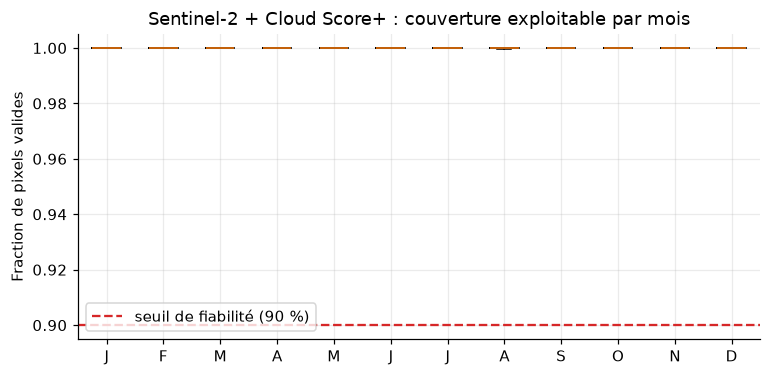

In [56]:
fig, ax = plt.subplots(figsize=(8, 3.6))
data = [panel.loc[panel.cal_month == m, "valid_frac"].values for m in range(1, 13)]
ax.boxplot(data, tick_labels=list("JFMAMJJASOND"), showfliers=False)
ax.axhline(0.9, ls="--", color=C_S1, label="seuil de fiabilité (90 %)")
ax.set_ylabel("Fraction de pixels valides")
ax.set_title("Sentinel-2 + Cloud Score+ : couverture exploitable par mois")
ax.legend(loc="lower left")
savefig(fig, "fig03_valid_fraction")
plt.show()

🛰️ *Pourquoi un seuil à 90 % ?* Les pixels masqués ne sont pas « secs » : ils sont **inconnus**. Une observation avec 70 % de pixels valides peut sous-estimer la surface en eau de 30 %. On ne garde comme **fiable** que les mois où ≥ 90 % de la zone est observée ; les autres seront reconstruits par le radar.

In [57]:
VALID_MIN = 0.90
panel["s2_reliable"] = panel["valid_frac"] >= VALID_MIN
print(f"Observations S2 fiables : {panel['s2_reliable'].mean():.1%}")
panel.groupby("cal_month")["s2_reliable"].mean().round(2).to_frame("part_fiable").T

Observations S2 fiables : 98.7%


cal_month,1,2,3,4,5,6,7,8,9,10,11,12
part_fiable,1.0,1.0,1.0,1.0,1.0,1.0,0.98,0.88,0.98,1.0,1.0,1.0


### 4.3 Sentinel-1 : choix du seuil et calibration

📡 *Quel seuil VV retenir ?* On compare, sur les mois où l'optique est fiable **et pendant la seule période d'entraînement** (pas de fuite d'information vers la validation), la surface radar à la surface optique pour chaque seuil. Critère : corrélation médiane par réservoir (on veut d'abord que le radar suive la **dynamique** de chaque réservoir) puis biais global.

In [58]:
is_train_period = panel["month"] <= TRAIN_END
calib = panel[panel["s2_reliable"] & is_train_period & panel["n_s1"].gt(0)]

rows = []
for t in S1_THRESHOLDS_DB:
    col = f"s1_water_{abs(t)}_ha"
    r_by_res = calib.groupby("reservoir_id").apply(
        lambda g: g["water_ha"].corr(g[col]) if g["water_ha"].std() > 0 else np.nan,
        include_groups=False,
    )
    rows.append({
        "seuil_dB": t,
        "r_median_par_reservoir": r_by_res.median(),
        "r_global": calib["water_ha"].corr(calib[col]),
        "biais_relatif_global": calib[col].sum() / calib["water_ha"].sum() - 1,
    })
s1_choice = pd.DataFrame(rows).round(3)
s1_choice

,seuil_dB,r_median_par_reservoir,r_global,biais_relatif_global
0,-14,-0.136,0.988,0.287
1,-16,0.400,0.993,0.085
2,-18,0.612,0.988,-0.083
3,-20,0.640,0.957,-0.245


In [59]:
best_thr = int(s1_choice.sort_values("r_median_par_reservoir", ascending=False)["seuil_dB"].iloc[0])
S1_COL = f"s1_water_{abs(best_thr)}_ha"
print(f"Seuil Sentinel-1 retenu : VV < {best_thr} dB ({S1_COL})")

Seuil Sentinel-1 retenu : VV < -20 dB (s1_water_20_ha)


📡 *Le radar et l'optique ne mesurent pas exactement la même chose* (végétation aquatique, berges humides, ombres radar). On apprend donc, **par réservoir**, une correspondance linéaire robuste S2 ≈ a + b·S1 (estimateur de **Theil-Sen**, insensible aux valeurs aberrantes), sur les mois fiables de la période d'entraînement. Si un réservoir a trop peu de mois communs ou une mauvaise corrélation (r < 0,6), le radar n'est pas utilisé pour lui.

In [60]:
MIN_CALIB_POINTS, MIN_CALIB_R = 12, 0.6


def fit_s1_mapping(g: pd.DataFrame) -> pd.Series:
    g = g.dropna(subset=["water_ha", S1_COL])
    if len(g) < MIN_CALIB_POINTS or g["water_ha"].std() == 0 or g[S1_COL].std() == 0:
        return pd.Series({"a": np.nan, "b": np.nan, "r": np.nan, "n": len(g)})
    with np.errstate(invalid="ignore"):   # IC de Theil-Sen non défini si beaucoup d'ex aequo (non utilisé)
        b, a, _, _ = stats.theilslopes(g["water_ha"], g[S1_COL])
    return pd.Series({"a": a, "b": b, "r": g["water_ha"].corr(g[S1_COL]), "n": len(g)})


s1_map = calib.groupby("reservoir_id").apply(fit_s1_mapping, include_groups=False)
s1_map["usable"] = s1_map["r"] >= MIN_CALIB_R
print(f"Réservoirs avec calibration radar exploitable : {s1_map['usable'].sum()} / {len(s1_map)}")
s1_map.describe().round(2)

Réservoirs avec calibration radar exploitable : 64 / 100


,a,b,r,n
count,100.00,100.00,100.00,100.00
mean,33.13,1.15,0.59,58.89
std,274.24,1.06,0.23,1.17
min,-14.46,-0.03,-0.48,55.00
25%,0.57,0.91,0.56,58.00
50%,2.06,1.10,0.64,59.00
75%,5.43,1.21,0.72,60.00
max,2745.08,9.43,0.87,60.00


🤖 **Évaluation indépendante du comblement radar.** Sur les mois **fiables de 2024 et après** (jamais vus lors de la calibration), on compare la surface optique observée à la surface reconstruite depuis le radar : c'est l'erreur qu'on commet quand on remplace un mois nuageux.

In [61]:
def s1_to_s2(df: pd.DataFrame) -> pd.Series:
    m = df[["reservoir_id"]].join(s1_map[["a", "b", "usable"]], on="reservoir_id")
    est = (m["a"] + m["b"] * df[S1_COL]).clip(lower=0)
    return est.where(m["usable"].fillna(False).astype(bool))


holdout = panel[panel["s2_reliable"] & ~is_train_period].copy()
holdout["s1_est_ha"] = s1_to_s2(holdout)
h = holdout.dropna(subset=["s1_est_ha"])
err = h["s1_est_ha"] - h["water_ha"]
print(f"n = {len(h)} | MAE = {err.abs().mean():.1f} ha | médiane erreur relative = {(err.abs() / h['water_ha'].clip(lower=1)).median():.1%}")
print(f"R² (log) = {r2_score(np.log1p(h['water_ha']), np.log1p(h['s1_est_ha'])):.3f}")

n = 2041 | MAE = 8.2 ha | médiane erreur relative = 55.2%


R² (log) = 0.420


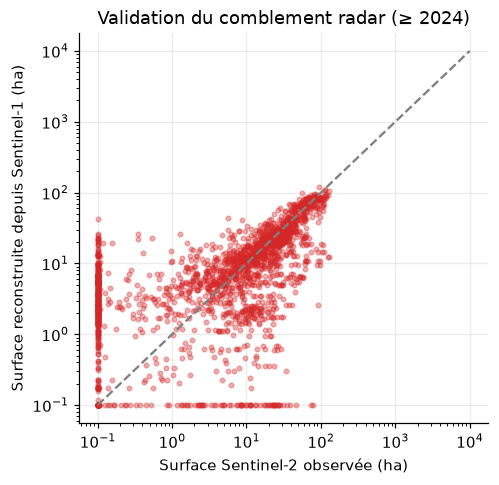

In [62]:
fig, ax = plt.subplots(figsize=(4.8, 4.6))
ax.loglog(h["water_ha"].clip(lower=0.1), h["s1_est_ha"].clip(lower=0.1), ".", alpha=0.35, color=C_S1)
ax.plot([0.1, 1e4], [0.1, 1e4], "--", color=C_REF)
ax.set_xlabel("Surface Sentinel-2 observée (ha)")
ax.set_ylabel("Surface reconstruite depuis Sentinel-1 (ha)")
ax.set_title("Validation du comblement radar (≥ 2024)")
savefig(fig, "fig04_s1_validation")
plt.show()

### 4.4 Série fusionnée

Règle de fusion, par ordre de priorité :
1. **S2** si l'observation optique est fiable ;
2. **S1** recalibré sinon (si la calibration du réservoir est exploitable) ;
3. **interpolation** temporelle linéaire si le trou ne dépasse pas 2 mois ;
4. sinon **manquant** (on ne fabrique pas de données).

On conserve la **provenance** de chaque valeur (`area_source`), indispensable pour la traçabilité scientifique.

In [63]:
panel["s1_est_ha"] = s1_to_s2(panel)
panel["area_ha"] = np.where(panel["s2_reliable"], panel["water_ha"], panel["s1_est_ha"])
panel["area_source"] = np.select(
    [panel["s2_reliable"], panel["s1_est_ha"].notna()], ["S2", "S1"], default="manquant"
)
panel["area_source"].value_counts(normalize=True).round(3).to_frame()

,proportion
area_source,
S2,0.987
S1,0.009
manquant,0.005


🤖 **Valeurs aberrantes.** Un filtre de **Hampel** (médiane glissante ± 4 × MAD sur 5 mois) détecte les pics isolés (ombre de nuage résiduelle, image radar bruitée). On ne remplace que les valeurs **non issues d'une observation optique fiable** : une observation S2 propre n'est jamais corrigée par un algorithme.

In [64]:
def hampel_flags(x: pd.Series, window: int = 5, n_sigma: float = 4.0) -> pd.Series:
    med = x.rolling(window, center=True, min_periods=3).median()
    mad = (x - med).abs().rolling(window, center=True, min_periods=3).median()
    scale = 1.4826 * mad
    return (x - med).abs() > n_sigma * scale.where(scale > 0, np.inf)


panel["outlier"] = panel.groupby("reservoir_id")["area_ha"].transform(hampel_flags) & ~panel["s2_reliable"]
print(f"Valeurs aberrantes détectées (hors S2 fiable) : {panel['outlier'].sum()}")
panel.loc[panel["outlier"], ["area_ha", "area_source"]] = [np.nan, "manquant"]

Valeurs aberrantes détectées (hors S2 fiable) : 4


In [65]:
def interpolate_short_gaps(x: pd.Series, limit: int = 2) -> pd.Series:
    # Interpolation linéaire limitée aux trous internes de <= limit mois
    filled = x.interpolate(limit=limit, limit_area="inside")
    gap_len = x.isna().groupby(x.notna().cumsum()).transform("sum")
    return filled.where(x.notna() | (gap_len <= limit))


before = panel["area_ha"].isna()
panel["area_ha"] = panel.groupby("reservoir_id")["area_ha"].transform(interpolate_short_gaps)
panel.loc[before & panel["area_ha"].notna(), "area_source"] = "interp"
panel["area_source"].value_counts(normalize=True).round(3).to_frame()

,proportion
area_source,
S2,0.987
S1,0.008
interp,0.005


### 4.5 Taux de remplissage et sélection des réservoirs modélisables

💧 *Comment comparer un barrage de 6 000 ha à une mare de 3 ha ?* On normalise par une **surface de référence** : le 95ᵉ centile de la surface fusionnée sur la **période d'entraînement** (le maximum serait sensible à une seule valeur aberrante). Le **taux de remplissage** `fill = area / A_ref` est sans dimension, comparable entre réservoirs et c'est la variable que le modèle prévoira.

🤖 *Pourquoi seulement sur l'entraînement ?* Calculer `A_ref` sur toute la série ferait « voir » au modèle l'amplitude des années de test : c'est une **fuite d'information** subtile mais réelle.

💧 *Quels réservoirs exclure ?* Ceux dont `A_ref` < 2 ha (≈ 50 pixels de 20 m) : en dessous, l'erreur de bord de pixel domine le signal.

In [66]:
A_REF_MIN_HA = 2.0

a_ref = (
    panel[panel["month"] <= TRAIN_END]
    .groupby("reservoir_id")["area_ha"].quantile(0.95)
    .rename("a_ref_ha")
)
res = res.drop(columns="a_ref_ha", errors="ignore").merge(a_ref, on="reservoir_id", how="left")
res["modelable"] = (res["a_ref_ha"] >= A_REF_MIN_HA) & ~res["overlap_flag"]
print(f"Réservoirs modélisables : {res['modelable'].sum()} / {len(res)}")
res.loc[~res["modelable"], ["reservoir_id", "source_ids", "osm_area_km2", "jrc_max_km2", "a_ref_ha"]].round(3)

Réservoirs modélisables : 96 / 100

,reservoir_id,source_ids,osm_area_km2,jrc_max_km2,a_ref_ha
18,R19,[25],0.001,0.000,0.102
26,R27,[35],0.000,0.000,0.010
52,J09,[],NaN,0.598,0.394
91,J48,[],NaN,0.172,0.010


In [67]:
panel = panel.drop(columns="a_ref_ha", errors="ignore").merge(a_ref, on="reservoir_id")
panel["fill"] = (panel["area_ha"] / panel["a_ref_ha"]).clip(upper=1.5)
data = panel[panel["reservoir_id"].isin(res.loc[res["modelable"], "reservoir_id"])].copy()
print(data.shape, "| taux de remplissage manquant :", f"{data['fill'].isna().mean():.1%}")

(8832, 33) | taux de remplissage manquant : 0.0%


🛰️ **Sensibilité au seuil MNDWI.** Si la dynamique dépend fortement du seuil (0 ± 0,1), les conclusions sont fragiles. On compare les taux de remplissage S2 obtenus avec les trois seuils sur les mois fiables.

In [68]:
sens = data[data["s2_reliable"]].copy()
rows = []
for col, thr in [("water_lo_ha", -0.1), ("water_hi_ha", 0.1)]:
    ref_alt = sens[sens.month <= TRAIN_END].groupby("reservoir_id")[col].quantile(0.95)
    fill_alt = sens[col] / sens["reservoir_id"].map(ref_alt)
    fill_ref = sens["water_ha"] / sens["a_ref_ha"]
    ok = fill_alt.notna() & np.isfinite(fill_alt)
    rows.append({
        "seuil": thr,
        "r_fill_vs_seuil_0": np.corrcoef(fill_ref[ok], fill_alt[ok])[0, 1],
        "MAE_fill": (fill_ref[ok] - fill_alt[ok]).abs().mean(),
        "rapport_A_ref": (ref_alt / sens.groupby("reservoir_id")["a_ref_ha"].first()).median(),
    })
pd.DataFrame(rows).round(3)

,seuil,r_fill_vs_seuil_0,MAE_fill,rapport_A_ref
0,-0.1,0.986,0.034,1.071
1,0.1,0.961,0.039,0.931


### 4.6 Effet de la résolution et contrôle de l'affinage à 10 m

📐 *Le passage de 20 m à 10 m change-t-il quelque chose ?* On ré-extrait deux mois contrastés (avril : étiage ; septembre : hautes eaux) à 20 m et on compare aux mesures à 10 m. On attend un effet faible sur les grands plans d'eau et fort sur les petits, dont le périmètre pèse lourd par rapport à la surface (pixels mixtes de bordure).

In [69]:
RES_MONTHS = [m for m in ("2024-04", "2024-09") if m in set(MONTHS.strftime("%Y-%m"))]
res_path = DATA_DIR / "s2_20m_compare.parquet"
if res_path.exists() and not FORCE_EXTRACT and set(res["reservoir_id"]) <= set(pd.read_parquet(res_path)["reservoir_id"]):
    s2_20 = pd.read_parquet(res_path)
else:
    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        s2_20 = pd.concat(pool.map(lambda m: ee_to_df(s2_month_features(ee.String(m), scale=20)), RES_MONTHS),
                          ignore_index=True)
    s2_20.to_parquet(res_path, index=False)
s2_20["water_20m_ha"] = s2_20["water_m2"] / 1e4

In [70]:
cmp_res = panel.merge(s2_20[["reservoir_id", "month", "water_20m_ha"]], on=["reservoir_id", "month"])
cmp_res = cmp_res[cmp_res["s2_reliable"] & (cmp_res["water_ha"] > 0.5)].copy()
cmp_res["ecart_rel"] = (cmp_res["water_20m_ha"] - cmp_res["water_ha"]).abs() / cmp_res["water_ha"]
cmp_res["taille"] = pd.cut(cmp_res["water_ha"], [0.5, 5, 50, 1e5], labels=["< 5 ha", "5-50 ha", "> 50 ha"])
cmp_res.groupby("taille", observed=True)["ecart_rel"].describe(percentiles=[0.5, 0.9])[["count", "50%", "90%", "max"]].round(3)

,count,50%,90%,max
taille,,,,
< 5 ha,19.0,0.043,0.121,0.268
5-50 ha,92.0,0.012,0.036,0.133
> 50 ha,23.0,0.004,0.013,0.019


📐 *L'affinage de la bande SWIR introduit-il un biais ?* On compare la surface MNDWI affinée à 10 m à la surface NDWI, dont les deux bandes sont **nativement** à 10 m. Une forte cohérence temporelle par réservoir valide l'affinage ; un écart systématique traduit la différence physique entre indices (le NDWI détecte moins bien l'eau turbide ou végétalisée), pas un artefact de résolution.

In [71]:
rel = panel[panel["s2_reliable"]]
r_idx = rel.groupby("reservoir_id").apply(
    lambda g: g["water_ha"].corr(g["water_ndwi_ha"]) if g["water_ha"].std() > 0 and g["water_ndwi_ha"].std() > 0 else np.nan,
    include_groups=False,
).dropna()
print(f"Corrélation temporelle MNDWI affiné / NDWI natif 10 m : médiane {r_idx.median():.3f} "
      f"| P10 {r_idx.quantile(0.1):.3f} (n = {len(r_idx)})")
print(f"Rapport des surfaces totales NDWI / MNDWI : {rel['water_ndwi_ha'].sum() / rel['water_ha'].sum():.3f}")

Corrélation temporelle MNDWI affiné / NDWI natif 10 m : médiane 0.830 | P10 0.611 (n = 100)


Rapport des surfaces totales NDWI / MNDWI : 0.800


### 4.7 De la surface au volume (ordre de grandeur)

💧 *Limite majeure d'une approche satellite : on mesure une surface, pas un stock.* Sans bathymétrie, on peut néanmoins obtenir un **ordre de grandeur** du volume grâce à une relation surface-volume régionale. **Liebe et al. (2005)** ont levé la bathymétrie de 61 petits réservoirs du bassin de la Volta (Upper East Region, Ghana — même socle, même relief que le plateau central burkinabè) et établi :

$$V = 0{,}00857 \times A^{1{,}4367} \qquad (V \text{ en m}^3,\ A \text{ en m}^2)$$

*Domaine de validité :* réservoirs de **1 à 35 ha**. En dehors (mares plus petites, grands barrages comme Ziga ou Loumbila), la relation est une extrapolation : on la calcule mais on la signale (`volume_valid = False`) et on ne l'utilise pas dans les totaux.

In [72]:
LIEBE_K, LIEBE_EXP = 0.00857, 1.4367
LIEBE_RANGE_HA = (1.0, 35.0)


def area_to_volume_m3(area_ha):
    return LIEBE_K * (np.asarray(area_ha, dtype=float) * 1e4) ** LIEBE_EXP


panel["volume_m3"] = area_to_volume_m3(panel["area_ha"])
panel["volume_valid"] = panel["a_ref_ha"].between(*LIEBE_RANGE_HA)
data["volume_m3"] = area_to_volume_m3(data["area_ha"])
data["volume_valid"] = data["a_ref_ha"].between(*LIEBE_RANGE_HA)
n_valid = data.loc[data["volume_valid"], "reservoir_id"].nunique()
print(f"Réservoirs dans le domaine de validité (A_ref de 1 à 35 ha) : {n_valid} / {data.reservoir_id.nunique()}")

Réservoirs dans le domaine de validité (A_ref de 1 à 35 ha) : 53 / 96


In [73]:
vol = data[data["volume_valid"]].groupby("cal_month")["volume_m3"].sum() / data[data["volume_valid"]].groupby("cal_month")["date"].nunique()
vol_table = (vol / 1e6).rename("volume total estimé (millions de m³)").to_frame().T
vol_table.columns = list("JFMAMJJASOND")
vol_table.round(2)

,J,F,M,A,M,J,J,A,S,O,N,D
volume total estimé (millions de m³),4.33,1.91,0.56,0.29,1.37,5.71,11.43,16.84,15.06,10.4,8.29,6.73


💧 *Lecture :* comme l'exposant est > 1, le volume chute **plus vite** que la surface pendant la récession : un réservoir à 50 % de sa surface de référence ne contient plus qu'environ 0,5^1,44 ≈ **37 %** de son volume. C'est une raison supplémentaire de placer le seuil critique assez haut (20 % de surface ≈ 10 % du volume).

In [74]:
# Sauvegarde du panel nettoyé (données de l'article)
PANEL_PATH = DATA_DIR / "panel_monthly.parquet"
panel.to_parquet(PANEL_PATH, index=False)
DATA_HASH = hashlib.sha256(pd.util.hash_pandas_object(panel, index=False).values.tobytes()).hexdigest()[:16]
print(f"Panel sauvegardé : {PANEL_PATH.name} | empreinte {DATA_HASH}")

Panel sauvegardé : panel_monthly.parquet | empreinte 166dad36ac1f5385


---
## 5. Analyse exploratoire hydrologique (Q1)

### 5.1 Vue d'ensemble

💧 *Que doit-on voir si les données sont physiquement cohérentes ?* Un cycle annuel net : remplissage en juillet-septembre en réponse aux pluies, pic en septembre-octobre, puis **récession** pendant toute la saison sèche sous l'effet de l'évaporation (≈ 6-8 mm/j) et des prélèvements (irrigation maraîchère, bétail, eau potable).

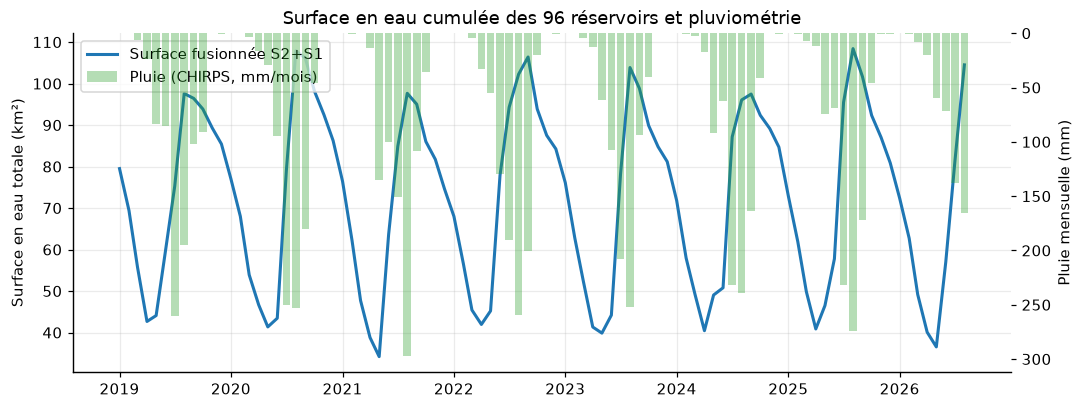

In [75]:
total = data.groupby("date").agg(
    area_ha=("area_ha", "sum"),
    s2_ha=("water_ha", lambda s: s.where(data.loc[s.index, "s2_reliable"]).sum(min_count=1)),
    precip_mm=("precip_mm", "mean"),
)
fig, ax = plt.subplots(figsize=(11, 4))
ax2 = ax.twinx()
ax2.bar(total.index, total["precip_mm"], width=25, color=C_RAIN, alpha=0.35, label="Pluie (CHIRPS, mm/mois)")
ax2.invert_yaxis()
ax2.set_ylabel("Pluie mensuelle (mm)")
ax2.grid(False)
ax.plot(total.index, total["area_ha"] / 100, color=C_S2, lw=2, label="Surface fusionnée S2+S1")
ax.set_ylabel("Surface en eau totale (km²)")
ax.set_title(f"Surface en eau cumulée des {data.reservoir_id.nunique()} réservoirs et pluviométrie")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left")
savefig(fig, "fig05_total_area_rain")
plt.show()

🗺️ Le réservoir R01 (≈ 60 km², vraisemblablement le barrage de Ziga) pèse à lui seul la majorité de la surface totale. Les analyses suivantes raisonnent donc en **taux de remplissage** (chaque réservoir compte autant).

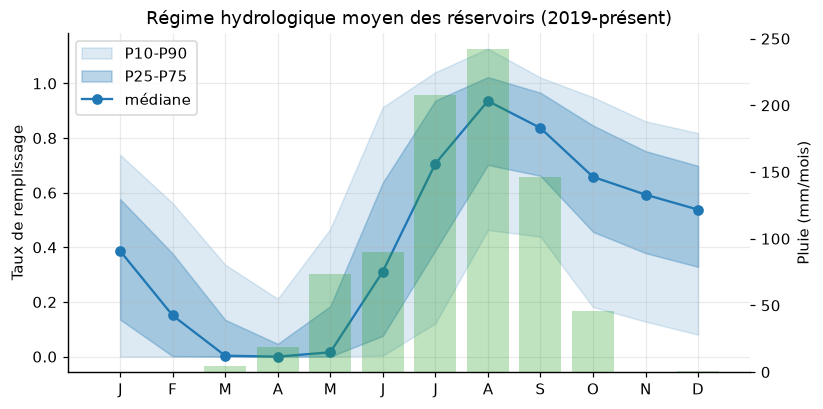

In [76]:
clim_fill = data.groupby("cal_month")["fill"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).unstack()
clim_rain = data.groupby(["cal_month", data["date"].dt.year])["precip_mm"].mean().groupby("cal_month").mean()

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(1, 13)
ax.fill_between(x, clim_fill[0.1], clim_fill[0.9], alpha=0.15, color=C_S2, label="P10-P90")
ax.fill_between(x, clim_fill[0.25], clim_fill[0.75], alpha=0.3, color=C_S2, label="P25-P75")
ax.plot(x, clim_fill[0.5], "-o", color=C_S2, label="médiane")
ax.set_xticks(x, list("JFMAMJJASOND"))
ax.set_ylabel("Taux de remplissage")
ax2 = ax.twinx()
ax2.bar(x, clim_rain, alpha=0.3, color=C_RAIN, label="pluie moyenne")
ax2.set_ylim(bottom=0)
ax2.set_ylabel("Pluie (mm/mois)")
ax2.grid(False)
ax.set_title("Régime hydrologique moyen des réservoirs (2019-présent)")
ax.legend(loc="upper left")
savefig(fig, "fig06_regime")
plt.show()

In [77]:
clim_fill.round(2).T

cal_month,1,2,3,4,5,6,7,8,9,10,11,12
0.10,0.00,0.00,0.00,0.00,0.00,0.00,0.12,0.46,0.44,0.18,0.13,0.08
0.25,0.14,0.00,0.00,0.00,0.00,0.08,0.39,0.70,0.66,0.46,0.38,0.33
0.50,0.39,0.15,0.00,0.00,0.02,0.31,0.71,0.94,0.84,0.66,0.59,0.54
0.75,0.58,0.38,0.13,0.05,0.18,0.64,0.94,1.02,0.97,0.85,0.75,0.70
0.90,0.74,0.56,0.34,0.21,0.47,0.91,1.04,1.13,1.02,0.95,0.86,0.82


### 5.2 Réponse aux pluies

💧 *Avec quel délai la surface répond-elle à la pluie ?* On calcule la corrélation croisée entre la pluie du mois *t − k* et la **variation** de surface du mois *t* (Δfill), pour chaque réservoir, puis on prend la médiane. Le décalage du pic renseigne sur le temps de réponse du bassin.

In [78]:
data["dfill"] = data.groupby("reservoir_id")["fill"].diff()
lags = range(0, 4)
xcorr = pd.DataFrame({
    k: data.groupby("reservoir_id").apply(
        lambda g: g["dfill"].corr(g["precip_mm"].shift(k)), include_groups=False
    )
    for k in lags
})
xcorr.median().round(3).rename("r médian (pluie t-k, Δfill t)").to_frame().T

,0,1,2,3
"r médian (pluie t-k, Δfill t)",0.486,0.182,-0.086,-0.181


💧 *Les années humides remplissent-elles davantage ?* Relation entre le cumul de pluie de juin à septembre et le **pic** de remplissage annuel (août-octobre), puis avec le **minimum** de la saison sèche suivante (avril-juin de l'année *n + 1*) : c'est ce dernier qui détermine la pénurie.

💧 *Définition de l'année hydrologique :* elle commence en **juillet** (début du remplissage), de sorte que le pic d'août-octobre de l'année *n* et le minimum d'avril-juin de *n + 1* appartiennent au même cycle. Les cycles incomplets (fin de série) sont exclus.

In [79]:
data["hydro_year"] = data["date"].dt.year.where(data["cal_month"] >= 7, data["date"].dt.year - 1)
year = data["date"].dt.year


def complete_agg(mask, by, col, func, n_months):
    g = data[mask].groupby(by)[col]
    return g.agg(func).where(g.count() == n_months)


rain_jjas = complete_agg(data.cal_month.between(6, 9), ["reservoir_id", year.rename("hydro_year")], "precip_mm", "sum", 4)
peak = complete_agg(data.cal_month.between(8, 10), ["reservoir_id", "hydro_year"], "fill", "max", 3)
low = complete_agg(data.cal_month.between(4, 6), ["reservoir_id", "hydro_year"], "fill", "min", 3)
annual = pd.concat({"rain_jjas": rain_jjas, "peak_fill": peak, "min_fill": low}, axis=1).dropna()
annual.groupby("hydro_year").median().round(2)

,rain_jjas,peak_fill,min_fill
hydro_year,,,
2019,650.20,0.88,0.0
2020,797.99,1.03,0.0
2021,655.63,0.89,0.0
2022,780.57,1.00,0.0
2023,664.48,0.98,0.0
2024,700.78,0.94,0.0
2025,752.66,1.01,0.0


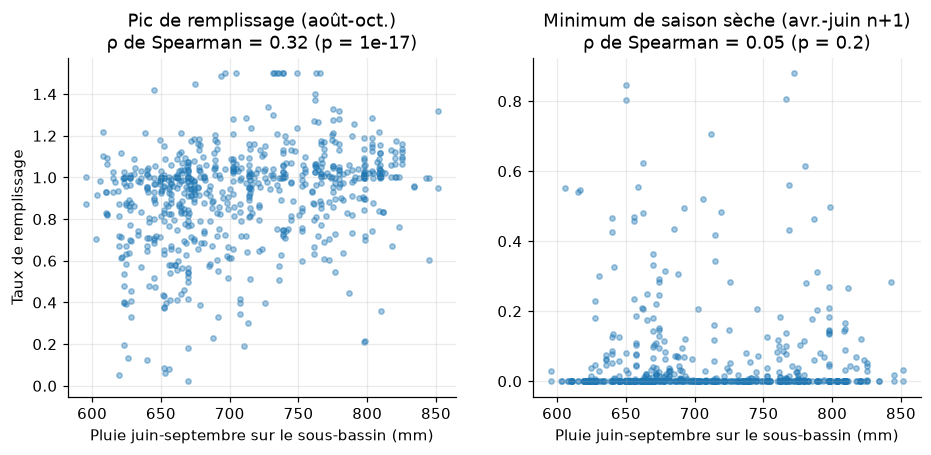

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
for ax, col, lab in zip(axes, ["peak_fill", "min_fill"], ["Pic de remplissage (août-oct.)", "Minimum de saison sèche (avr.-juin n+1)"]):
    ax.scatter(annual["rain_jjas"], annual[col], s=12, alpha=0.4, color=C_S2)
    rho, p = stats.spearmanr(annual["rain_jjas"], annual[col])
    ax.set_title(f"{lab}\nρ de Spearman = {rho:.2f} (p = {p:.1g})")
    ax.set_xlabel("Pluie juin-septembre sur le sous-bassin (mm)")
axes[0].set_ylabel("Taux de remplissage")
savefig(fig, "fig07_rain_vs_fill")
plt.show()

### 5.3 Récession de saison sèche

💧 *À quelle vitesse les réservoirs se vident-ils ?* De novembre à mai, sans apport, la perte de surface reflète évaporation + prélèvements + infiltration. On calcule la perte mensuelle **relative** médiane et on la met en regard de l'évaporation potentielle ERA5.

In [81]:
dry = data[data["cal_month"].isin([11, 12, 1, 2, 3, 4, 5])]
recession = dry.groupby("cal_month").agg(
    dfill_median=("dfill", "median"),
    pet_mm=("pet_mm", "mean"),
    t2m_c=("t2m_c", "mean"),
).reindex([11, 12, 1, 2, 3, 4, 5])
recession.round(3)

,dfill_median,pet_mm,t2m_c
cal_month,,,
11,-0.059,326.739,28.534
12,-0.065,381.240,26.615
1,-0.126,414.768,26.120
2,-0.153,415.483,28.304
3,-0.088,413.593,32.141
4,0.000,402.595,33.525
5,0.000,406.900,32.997


### 5.4 Taille et permanence

💧 *Les petits réservoirs sont-ils plus vulnérables ?* Hypothèse classique : le rapport surface/volume est plus élevé pour les petites retenues peu profondes → l'évaporation les assèche plus vite. On teste la relation entre la taille (`A_ref`) et le remplissage minimal médian de saison sèche.

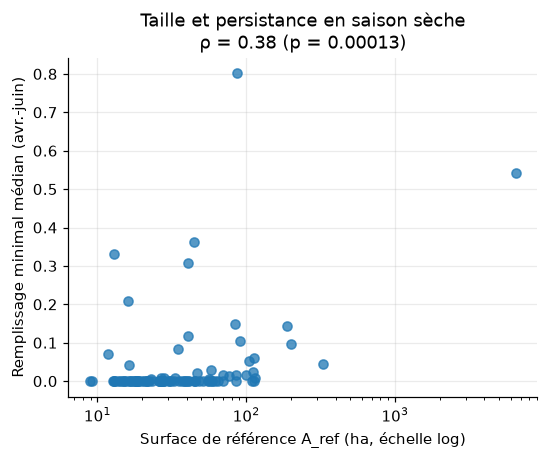

In [82]:
per_res = annual.groupby("reservoir_id")["min_fill"].median().rename("min_fill_med").to_frame().join(
    res.set_index("reservoir_id")[["a_ref_ha", "jrc_occ_mean"]]
)
rho, p = stats.spearmanr(np.log10(per_res["a_ref_ha"]), per_res["min_fill_med"])

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.semilogx(per_res["a_ref_ha"], per_res["min_fill_med"], "o", color=C_S2, alpha=0.75)
ax.set_xlabel("Surface de référence A_ref (ha, échelle log)")
ax.set_ylabel("Remplissage minimal médian (avr.-juin)")
ax.set_title(f"Taille et persistance en saison sèche\nρ = {rho:.2f} (p = {p:.2g})")
savefig(fig, "fig08_size_vs_min")
plt.show()

### 5.5 Tendances interannuelles

💧 *Les réservoirs se dégradent-ils (envasement, prélèvements croissants) ?* Test non paramétrique de **Mann-Kendall** et pente de **Theil-Sen** sur le minimum annuel de saison sèche, par réservoir.

🤖 *Prudence statistique :* avec ~7 années, la puissance du test est faible et on teste plusieurs dizaines de réservoirs → on corrige les p-valeurs par **Benjamini-Hochberg** (taux de fausses découvertes) pour ne pas « trouver » des tendances par hasard.

In [83]:
def mann_kendall(g: pd.DataFrame) -> pd.Series:
    g = g.dropna()
    if len(g) < 5:
        return pd.Series({"tau": np.nan, "p": np.nan, "sen_slope": np.nan, "n_years": len(g)})
    tau, p = stats.kendalltau(g["hydro_year"], g["min_fill"])
    slope = stats.theilslopes(g["min_fill"], g["hydro_year"])[0]
    return pd.Series({"tau": tau, "p": p, "sen_slope": slope, "n_years": len(g)})


trends = annual.reset_index().groupby("reservoir_id").apply(mann_kendall, include_groups=False).dropna()
trends["p_bh"] = stats.false_discovery_control(trends["p"])
print(f"Réservoirs testés : {len(trends)} | tendance significative (FDR 10 %) : {(trends['p_bh'] < 0.1).sum()}")
trends.sort_values("p").head(8).round(3)

Réservoirs testés : 72 | tendance significative (FDR 10 %) : 0


,tau,p,sen_slope,n_years,p_bh
reservoir_id,,,,,
R03,0.823,0.012,0.007,7.0,0.602
R37,0.720,0.028,0.031,7.0,0.602
R43,0.683,0.033,0.005,7.0,0.602
R20,0.683,0.033,0.086,7.0,0.602
R40,0.586,0.068,0.005,7.0,0.829
R25,0.619,0.069,0.052,7.0,0.829
R07,0.514,0.117,0.003,7.0,0.907
J08,-0.535,0.134,0.000,7.0,0.907


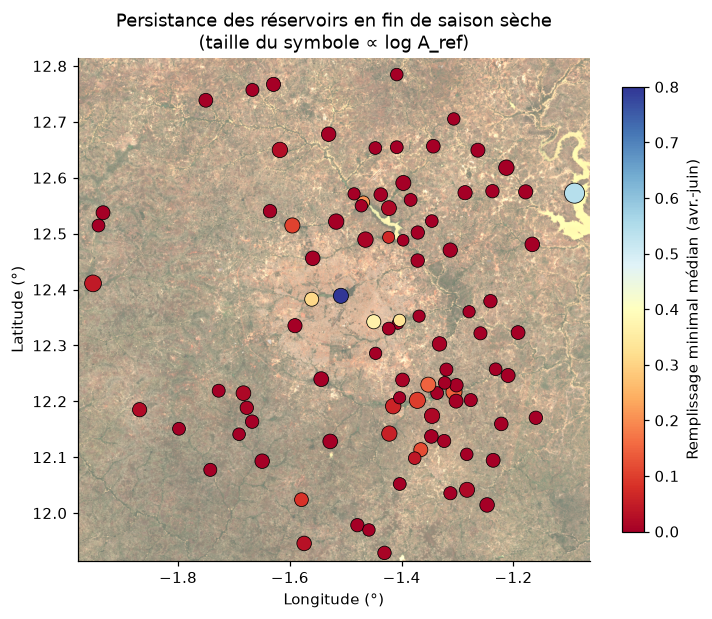

In [84]:
# Carte : persistance de saison sèche par réservoir
per_res_map = res.set_index("reservoir_id").join(per_res["min_fill_med"]).dropna(subset=["min_fill_med"])
pts = per_res_map.to_crs(CRS_UTM).geometry.centroid.to_crs(CRS_WGS84)

fig, ax = plt.subplots(figsize=(7.5, 7))
draw_background(ax, alpha=0.55)
sc = ax.scatter(pts.x, pts.y, c=per_res_map["min_fill_med"], cmap="RdYlBu", vmin=0, vmax=0.8,
                s=20 + 40 * np.log10(per_res_map["a_ref_ha"]), edgecolor="k", lw=0.5)
plt.colorbar(sc, ax=ax, shrink=0.75, label="Remplissage minimal médian (avr.-juin)")
ax.set_title("Persistance des réservoirs en fin de saison sèche\n(taille du symbole ∝ log A_ref)")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.grid(False)
savefig(fig, "fig09_map_persistence")
plt.show()

---
## 6. Diagnostic critique de l'approche historique (v2 en production)

Avant de proposer un nouveau modèle, l'ingénieur IA **audite l'existant** (`ml/train.py`, `app/services/ml.py`) en le ré-exécutant sur les données de la base. Chaque problème est **démontré par un chiffre**, pas seulement affirmé.

| # | Problème suspecté | Spécialiste |
|---|---|---|
| D1 | La cible « périodes avant tarissement (NDWI < 0,2) » est quasi déterminée par la saison | 💧 |
| D2 | `ndwi_moy_src` (moyenne de **toute** la série, futur compris) et le découpage aléatoire créent une **fuite d'information** | 🤖 |
| D3 | À l'inférence, le service normalise les entrées (`scaler`) même quand le modèle retenu est la forêt aléatoire, entraînée sur données **non** normalisées | 💻 |
| D4 | Le NDWI ponctuel au centroïde suit-il la surface en eau du réservoir ? | 🗺️ |

In [85]:
from ml.train import FEATURES as LEGACY_FEATURES, build_features, load_observations

legacy_raw = load_observations()
legacy, _, _ = build_features(legacy_raw)
print(f"Observations v2 : {len(legacy_raw)} | après construction des variables : {len(legacy)}")
legacy_raw.groupby("saison")["ndwi"].describe().round(3)

Observations v2 : 650 | après construction des variables : 455


,count,mean,std,min,25%,50%,75%,max
saison,,,,,,,,
pluies,325.0,0.346,0.183,-0.563,0.290,0.390,0.453,0.647
seche,325.0,0.079,0.175,-0.482,-0.036,0.088,0.202,0.532


**D1 — Cible saisonnière.** En saison sèche le NDWI ponctuel moyen est ≈ 0,08, donc presque toujours sous le seuil de 0,2 : après chaque semestre de pluies, la « période suivante » (sèche) est déclarée « tarie ».

In [86]:
pd.crosstab(legacy["saison"], legacy["periods_until_dry"].clip(upper=3).astype(int), normalize="index").round(3)

periods_until_dry,1,2,3
saison,,,
pluies,0.723,0.021,0.256
seche,0.135,0.431,0.435


In [87]:
# Une règle triviale sans aucun apprentissage : prédire la valeur modale de la cible pour chaque saison
mode_by_season = legacy.groupby("saison")["periods_until_dry"].agg(lambda s: s.mode().iloc[0])
trivial = legacy["saison"].map(mode_by_season)
print(f"Exactitude de la règle « saison seule » : {(trivial == legacy['periods_until_dry']).mean():.1%}")

Exactitude de la règle « saison seule » : 55.6%


**D2 — Fuite d'information.** On ré-entraîne exactement la forêt aléatoire de la v2 avec (a) le découpage aléatoire d'origine et (b) un découpage **temporel** honnête (entraînement sur les périodes ≤ 2023-S1, test sur les suivantes), avec et sans la variable `ndwi_moy_src`.

In [88]:
from sklearn.model_selection import train_test_split


def legacy_rf():
    return RandomForestRegressor(n_estimators=150, max_depth=15, min_samples_split=5, random_state=SEED, n_jobs=N_JOBS)


def score_legacy(features, split):
    X, y = legacy[features].fillna(0.0), legacy["periods_until_dry"]
    if split == "aléatoire":
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED)
    else:
        tr = legacy["periode"] <= "2023-S1"
        Xtr, Xte, ytr, yte = X[tr], X[~tr], y[tr], y[~tr]
    pred = legacy_rf().fit(Xtr, ytr).predict(Xte)
    return mean_absolute_error(yte, pred), r2_score(yte, pred)


no_leak = [f for f in LEGACY_FEATURES if f != "ndwi_moy_src"]
rows = []
for split in ["aléatoire", "temporel"]:
    for name, feats in [("12 variables v2", LEGACY_FEATURES), ("sans ndwi_moy_src", no_leak)]:
        mae, r2 = score_legacy(feats, split)
        rows.append({"découpage": split, "variables": name, "MAE": mae, "R²": r2})
pd.DataFrame(rows).round(3)

,découpage,variables,MAE,R²
0,aléatoire,12 variables v2,4.932,0.190
1,aléatoire,sans ndwi_moy_src,5.037,0.175
2,temporel,12 variables v2,8.603,-0.452
3,temporel,sans ndwi_moy_src,8.697,-0.398


**D3 — Incohérence entraînement / inférence.** `ml/train.py` entraîne la forêt aléatoire sur `X_train` brut, mais `PeriodsUntilDryService.predict_periods_until_dry` applique systématiquement `scaler.transform`. On mesure l'écart entre la prédiction correcte et celle réellement servie par l'API.

In [89]:
X_all = legacy[LEGACY_FEATURES].fillna(0.0)
rf = legacy_rf().fit(X_all, legacy["periods_until_dry"])
scaler_v2 = StandardScaler().fit(X_all)
correct = rf.predict(X_all)
served = rf.predict(pd.DataFrame(scaler_v2.transform(X_all), columns=LEGACY_FEATURES))   # ce que faisait l'API v2
print(f"Écart moyen entre prédiction correcte et prédiction servie : {np.abs(correct - served).mean():.2f} périodes")
print(f"Part des prédictions servies identiques (arrondies) : {(np.round(correct) == np.round(served)).mean():.1%}")

Écart moyen entre prédiction correcte et prédiction servie : 6.07 périodes
Part des prédictions servies identiques (arrondies) : 0.4%


**D4 — Le NDWI ponctuel suit-il la surface en eau ?** On agrège notre taux de remplissage mensuel par semestre (S1 = janv.-juin, S2 = juil.-déc., comme la v2) et on le compare au NDWI ponctuel de la v2 pour les mêmes sources.

In [90]:
src_to_res = {sid: rid for rid, ids in zip(res["reservoir_id"], res["source_ids"]) for sid in ids}
sem = data.assign(periode=data["date"].dt.year.astype(str) + "-S" + np.where(data["cal_month"] <= 6, "1", "2"))
sem = sem.groupby(["reservoir_id", "periode"])["fill"].mean().rename("fill_semestre").reset_index()

cmp_v2 = legacy_raw.assign(reservoir_id=legacy_raw["source_id"].map(src_to_res)).merge(sem, on=["reservoir_id", "periode"])
r_within = cmp_v2.groupby("reservoir_id").apply(lambda g: g["ndwi"].corr(g["fill_semestre"]), include_groups=False)
print(f"Corrélation globale NDWI ponctuel v2 / remplissage : {cmp_v2['ndwi'].corr(cmp_v2['fill_semestre']):.2f}")
print(f"Corrélation intra-réservoir médiane : {r_within.median():.2f} | part des réservoirs avec r < 0,5 : {(r_within < 0.5).mean():.0%}")

Corrélation globale NDWI ponctuel v2 / remplissage : 0.66
Corrélation intra-réservoir médiane : 0.83 | part des réservoirs avec r < 0,5 : 14%


🗺️ *Attention à l'interprétation.* Une corrélation élevée entre semestres peut venir uniquement du **contraste saisonnier** (tous les semestres « pluies » sont hauts, tous les « secs » bas). Le test pertinent pour une alerte est : le NDWI ponctuel distingue-t-il une **bonne d'une mauvaise saison sèche** ? On recalcule la corrélation au sein des seuls semestres secs.

In [91]:
dry_v2 = cmp_v2[cmp_v2["saison"] == "seche"]
r_dry = dry_v2.groupby("reservoir_id").apply(
    lambda g: g["ndwi"].corr(g["fill_semestre"]) if g["fill_semestre"].std() > 0 else np.nan,
    include_groups=False,
).dropna()
print(f"Saison sèche uniquement : r médian intra-réservoir = {r_dry.median():.2f} "
      f"| part des réservoirs avec r < 0,5 : {(r_dry < 0.5).mean():.0%} (n = {len(r_dry)})")

Saison sèche uniquement : r médian intra-réservoir = 0.39 | part des réservoirs avec r < 0,5 : 60% (n = 42)


**Bilan du diagnostic.**
- **D1 confirmé** : la cible dépend surtout de la saison ; une règle sans apprentissage atteint déjà le niveau indiqué ci-dessus.
- **D2 confirmé** : le R² publié (0,19) vient du découpage aléatoire ; en découpage temporel honnête, le modèle fait **moins bien que la moyenne** (R² négatif). `ndwi_moy_src` n'a qu'un effet marginal ici : c'est l'autocorrélation entre lignes qui gonfle le score.
- **D3 confirmé, et le plus grave** : les prédictions servies par l'API n'avaient presque aucun rapport avec celles du modèle (corrigé dans `app/services/ml.py`).
- **D4 nuancé** : à l'échelle semestrielle, le NDWI ponctuel suit correctement le remplissage (corrélation dominée par la saisonnalité) ; sa capacité à discriminer les saisons sèches entre elles est mesurée ci-dessus. Sa vraie limite est **temporelle** : un pas semestriel ne peut pas dater un assèchement ni alerter 1 à 3 mois à l'avance.

Conséquences pour la nouvelle chaîne :
- passer à une **surface en eau mensuelle** fusionnée optique/radar ;
- remplacer la cible « périodes avant NDWI < 0,2 » (censurée à 20) par une **prévision directe du taux de remplissage** à 1-3 mois ;
- n'utiliser que des variables **connues au moment de la prévision** et un **découpage temporel** ;
- encapsuler prétraitement + modèle dans un **unique `Pipeline` scikit-learn** sérialisé, pour qu'il soit impossible d'appliquer un autre prétraitement à l'inférence.

---
## 7. Formulation du problème de prévision (Q3, Q4)

💧 *Que veut savoir un gestionnaire ?* « Dans 1, 2 ou 3 mois, quel sera l'état de ce réservoir, et y a-t-il un risque qu'il atteigne un **niveau critique** ? » → deux tâches :
1. **Régression** : prévoir le taux de remplissage `fill(t+h)`, h ∈ {1, 2, 3} mois, avec un **intervalle de prédiction** ;
2. **Alerte** : probabilité que `fill(t+h)` < seuil critique.

🤖 *Stratégie multi-horizon ?* **Directe** : un modèle par horizon (pas de propagation d'erreur d'un mois à l'autre comme en stratégie récursive).

🤖 *Prévoir le niveau ou la variation ?* La persistance (« rien ne change ») est très forte à 1 mois pour un stock d'eau. On teste les deux formulations : prévoir le **niveau** `fill(t+h)` ou la **variation** `fill(t+h) − fill(t)` ; le choix se fait sur la validation.

💧 *Quel seuil critique ?* On retient **20 % de la surface de référence**. En dessous, il ne reste en général qu'une mare résiduelle dans la cuvette (eau de mauvaise qualité, inaccessible au bétail, usages en concurrence). On vérifie que l'événement n'est ni trop rare ni trop fréquent pour être évalué.

In [92]:
CRITICAL_FILL = 0.20
print(f"Fréquence de fill < {CRITICAL_FILL:.0%} : {(data['fill'] < CRITICAL_FILL).mean():.1%} des réservoir-mois")
(data.assign(crit=data["fill"] < CRITICAL_FILL).groupby("cal_month")["crit"].mean().round(2).to_frame("part critique").T)

Fréquence de fill < 20% : 37.1% des réservoir-mois


cal_month,1,2,3,4,5,6,7,8,9,10,11,12
part critique,0.31,0.55,0.8,0.89,0.76,0.38,0.15,0.03,0.04,0.1,0.13,0.17


---
## 8. Variables explicatives

💻 Le calcul des variables est dans **`ml/features.py`**, importé ici. Raison : le modèle sauvegardé sera rechargé par l'API, qui devra calculer **exactement** les mêmes variables ; une seule implémentation évite la classe de bug D3 (§6).

🤖 *Règle d'or :* toute variable de la ligne émise au mois *t* n'utilise que l'information disponible **à la fin du mois t**. Les pluies futures sont inconnues : on ne fournit que leur **climatologie**.

| Groupe | Variables | Justification |
|---|---|---|
| État | `fill_l0..l3`, `fill_l12`, `dfill_1`, `dfill_3` | inertie du stock, tendance récente, mémoire interannuelle |
| Climatologie | `clim_issue`, `clim_target`, `anom_issue` | régime propre au réservoir ; l'anomalie indique une année en avance/retard |
| Forçages passés | pluie (1, 3, 6 mois, anomalie), ETP, ET réelle, T2m, humidité du sol | apports récents et demande évaporative |
| Calendrier | sin/cos des mois d'émission et cible | position dans le cycle hydrologique |
| Physique | log A_ref, permanence JRC, altitude, pente, bassin, rapport bassin/plan d'eau | différences structurelles entre réservoirs |
| Qualité | `is_s2` | l'état initial vient-il d'une observation optique directe ? |

🤖 *Climatologie et fuite :* pour les lignes d'entraînement, `clim_target` est calculée **en excluant l'année de la cible** (*leave-one-year-out*).

In [93]:
import importlib
import ml.features as F
importlib.reload(F)

print(f"{len(F.FEATURES)} variables")

32 variables

In [94]:
static = F.static_features(res[res["modelable"]])
climatology = F.fit_climatology(data, TRAIN_END)
static.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
log_a_ref,96.0,1.55,0.40,0.95,1.27,1.48,1.75,3.81
jrc_occ_mean,95.0,34.28,14.23,4.98,24.67,33.06,41.61,90.50
jrc_seasonality,95.0,4.61,1.59,1.25,3.60,4.53,5.27,11.39
elev_m,96.0,292.65,16.11,263.50,280.78,288.08,301.87,338.02
slope_deg,96.0,2.33,0.77,1.08,1.77,2.10,2.88,4.54
log_basin_km2,96.0,2.21,0.22,1.34,2.10,2.23,2.32,2.64
log_upstream_km2,96.0,2.62,0.46,2.01,2.28,2.53,2.91,4.31
log_catchment_ratio,96.0,2.66,0.47,0.53,2.46,2.69,2.98,3.42


In [95]:
rows_by_h = {
    h: F.build_rows(data, h, climatology, static, train_end=TRAIN_END)
    for h in HORIZONS
}
rows_by_h[1][["reservoir_id", "date", "target_date", "fill_l0", "clim_target", "y"]].dropna().head()

,reservoir_id,date,target_date,fill_l0,clim_target,y
0,J01,2019-01-01,2019-02-01,0.008491,0.000000,0.000000
1,J01,2019-02-01,2019-03-01,0.000000,0.000000,0.000000
2,J01,2019-03-01,2019-04-01,0.000000,0.000000,0.000000
3,J01,2019-04-01,2019-05-01,0.000000,0.000000,0.000000
4,J01,2019-05-01,2019-06-01,0.000000,0.023586,0.031134


In [96]:
# Contrôle anti-fuite : une variable quasi identique à la cible (|r| > 0,95) trahirait une fuite
r1 = rows_by_h[1].dropna(subset=["y"])
corr = r1[F.FEATURES].corrwith(r1["y"]).sort_values(ascending=False)
assert corr.abs().max() < 0.95, "corrélation suspecte : fuite probable"
corr.head(8).round(3).to_frame("corr. avec fill(t+1)")

,corr. avec fill(t+1)
clim_target,0.796
fill_l0,0.724
clim_issue,0.654
dfill_3,0.634
fill_l12,0.606
precip_mm,0.578
precip_3m,0.577
aet_mm,0.572


---
## 9. Protocole de validation

🤖 *Pourquoi pas un découpage aléatoire ?* Les observations d'un même réservoir sont autocorrélées : avec un découpage aléatoire, le mois d'avril 2023 serait en test alors que mars et mai 2023 sont en entraînement → performances **surestimées** (démontré en §6, D2).

Découpage **temporel** selon le mois **cible** :

| Jeu | Mois cibles | Usage |
|---|---|---|
| Entraînement | 2019 → 2023 | apprentissage |
| Validation | 2024 | choix des hyperparamètres, de la formulation, du seuil d'alerte, calibration conforme |
| Test | 2025 → dernier mois | **évaluation finale, utilisée une seule fois** |

La généralisation à des réservoirs **jamais vus** est évaluée séparément (§12, validation croisée groupée par réservoir).

In [97]:
def split_of(target_date: pd.Series) -> pd.Series:
    tm = target_date.dt.to_period("M").astype(str)
    return pd.Series(np.select([tm <= TRAIN_END, tm <= VALID_END], ["train", "valid"], "test"), index=target_date.index)


sets = {}
for h, df in rows_by_h.items():
    df = df.dropna(subset=["y", "fill_l0"]).copy()
    df["split"] = split_of(df["target_date"])
    sets[h] = df

pd.DataFrame({h: df["split"].value_counts() for h, df in sets.items()}).add_prefix("h=").T

split,train,test,valid
h=1,5664,1920,1152
h=2,5568,1920,1152
h=3,5472,1920,1152


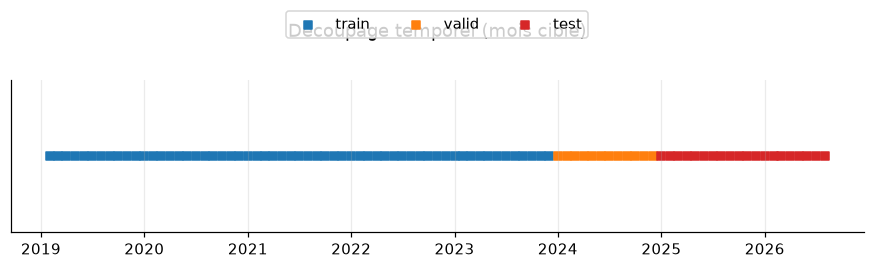

In [98]:
fig, ax = plt.subplots(figsize=(10, 1.8))
colors = {"train": C_S2, "valid": "#ff7f0e", "test": C_S1}
d = sets[1].groupby("target_date")["split"].first()
for s, c in colors.items():
    ax.scatter(d.index[d == s], np.zeros((d == s).sum()), color=c, marker="s", s=30, label=s)
ax.set_yticks([])
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.5))
ax.set_title("Découpage temporel (mois cible)", pad=28)
savefig(fig, "fig10_split")
plt.show()

---
## 10. Références (baselines) et modèles

### 10.1 Métriques

- **MAE** (erreur absolue moyenne, en points de remplissage) : métrique principale, robuste et interprétable ;
- **RMSE**, **NSE** (Nash-Sutcliffe, standard en hydrologie, = R²) et **KGE** (Kling-Gupta, Gupta et al., 2009) qui décompose l'erreur en corrélation, biais et variabilité ;
- **Skill score** : `1 − MAE_modèle / MAE_référence` (> 0 : le modèle apporte quelque chose). La référence est la **meilleure baseline sur la validation** pour chaque horizon : comparer à une référence faible gonflerait artificiellement le skill.

In [99]:
def kge(obs, sim):
    obs, sim = np.asarray(obs), np.asarray(sim)
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = sim.std() / obs.std()
    beta = sim.mean() / obs.mean()
    return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)


def regression_metrics(obs, sim) -> dict:
    return {
        "MAE": mean_absolute_error(obs, sim),
        "RMSE": np.sqrt(mean_squared_error(obs, sim)),
        "NSE": r2_score(obs, sim),
        "KGE": kge(obs, sim),
    }

### 10.2 Références hydrologiques

Un modèle d'IA n'a de valeur que s'il bat des références simples **et fortes** :
- **Persistance** : `fill(t+h) = fill(t)` ;
- **Saison naïve** : la valeur du même mois l'an passé ;
- **Climatologie** : la médiane du réservoir pour le mois cible ;
- **Anomalie persistante** : climatologie du mois cible + anomalie actuelle (l'écart à la normale se maintient).

In [100]:
def baselines(df: pd.DataFrame) -> dict[str, pd.Series]:
    return {
        "Persistance": df["fill_l0"],
        "Saison naïve": df["fill_target_lastyear"].fillna(df["clim_target"]),
        "Climatologie": df["clim_target"].fillna(df["fill_l0"]),
        "Anomalie persistante": (df["clim_target"] + df["anom_issue"]).fillna(df["fill_l0"]).clip(0, 1.5),
    }

In [101]:
rows = []
for h, df in sets.items():
    for split in ["valid", "test"]:
        d = df[df["split"] == split]
        for name, pred in baselines(d).items():
            rows.append({"h": h, "jeu": split, "modèle": name, **regression_metrics(d["y"], pred)})
baseline_scores = pd.DataFrame(rows)
baseline_scores[baseline_scores.jeu == "valid"].pivot(index="modèle", columns="h", values="MAE").round(3)

h,1,2,3
modèle,,,
Anomalie persistante,0.137,0.167,0.175
Climatologie,0.134,0.134,0.134
Persistance,0.164,0.268,0.343
Saison naïve,0.148,0.148,0.148


💧 *Lecture :* au pas mensuel, la **persistance est une référence faible** : en saison des pluies, la surface peut doubler en un mois. La **climatologie** du réservoir (ou la saison naïve) est bien plus exigeante. C'est elle que le modèle doit battre.

In [102]:
valid_mae = baseline_scores[baseline_scores.jeu == "valid"].set_index(["h", "modèle"])["MAE"]
BEST_BASELINE = {h: valid_mae.loc[h].idxmin() for h in HORIZONS}
print("Meilleure référence (validation) :", BEST_BASELINE)

Meilleure référence (validation) : {1: 'Climatologie', 2: 'Climatologie', 3: 'Climatologie'}


### 10.3 Modèles d'apprentissage

| Modèle | Pourquoi |
|---|---|
| **Ridge** | modèle linéaire régularisé : référence interprétable, révèle si la relation est essentiellement linéaire |
| **Forêt aléatoire** | non linéaire, robuste, peu sensible aux hyperparamètres (modèle de la v2) |
| **Gradient boosting histogramme** (`HistGradientBoostingRegressor`) | état de l'art sur données tabulaires, gère nativement les valeurs manquantes, permet la **régression quantile** |

💻 Chaque modèle est un **`Pipeline`** (imputation + normalisation si nécessaire + estimateur) : le prétraitement est sérialisé avec le modèle.

In [103]:
from sklearn.impute import SimpleImputer


def make_model(kind: str, params: dict):
    if kind == "Ridge":
        return Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler()), ("model", Ridge(**params))])
    if kind == "RandomForest":
        return Pipeline([("impute", SimpleImputer(strategy="median")),
                         ("model", RandomForestRegressor(n_estimators=300, n_jobs=N_JOBS, random_state=SEED, **params))])
    if kind == "HGB":
        return Pipeline([("model", HistGradientBoostingRegressor(**{"max_iter": 600, "early_stopping": False, "random_state": SEED, **params}))])
    raise ValueError(kind)

In [104]:
GRID = {
    "Ridge": [{"alpha": a} for a in (0.1, 1.0, 10.0)],
    "RandomForest": [{"max_depth": d, "min_samples_leaf": m, "max_features": 0.5}
                     for d in (8, None) for m in (5, 20)],
    "HGB": [{"learning_rate": lr, "max_leaf_nodes": n, "min_samples_leaf": m, "l2_regularization": 1.0, "max_iter": it}
            for lr, it in ((0.03, 600), (0.1, 200)) for n in (15, 31) for m in (20, 50)],
}
TARGET_MODES = ["level", "delta"]
print(sum(len(v) for v in GRID.values()) * len(TARGET_MODES) * len(HORIZONS), "configurations évaluées")

90 configurations évaluées


🤖 La sélection se fait **uniquement sur la validation (2024)**. Le mode `delta` apprend `fill(t+h) − fill(t)` ; la prédiction est ensuite reconstruite et bornée à [0 ; 1,5].

In [105]:
def fit_predict(kind, params, mode, train, test):
    y = train["y"] - train["fill_l0"] if mode == "delta" else train["y"]
    model = make_model(kind, params).fit(train[F.FEATURES], y)
    pred = model.predict(test[F.FEATURES])
    if mode == "delta":
        pred = pred + test["fill_l0"].values
    return model, np.clip(pred, 0, 1.5)

In [106]:
t0 = time.time()
search = []
for h, df in sets.items():
    tr, va = df[df.split == "train"], df[df.split == "valid"]
    for kind, grid in GRID.items():
        for params in grid:
            for mode in TARGET_MODES:
                _, pred = fit_predict(kind, params, mode, tr, va)
                search.append({"h": h, "kind": kind, "params": params, "mode": mode,
                               "MAE_valid": mean_absolute_error(va["y"], pred)})
search = pd.DataFrame(search)
print(f"Recherche terminée en {time.time() - t0:.0f}s")

Recherche terminée en 158s


In [107]:
best_cfg = search.loc[search.groupby(["h", "kind"])["MAE_valid"].idxmin()]
best_cfg[["h", "kind", "mode", "MAE_valid", "params"]].round(4)

,h,kind,mode,MAE_valid,params
19,1,HGB,delta,0.1178,"{'learning_rate': 0.03, 'max_leaf_nodes': 31, ..."
10,1,RandomForest,level,0.1141,"{'max_depth': None, 'min_samples_leaf': 5, 'ma..."
5,1,Ridge,delta,0.1189,{'alpha': 10.0}
48,2,HGB,level,0.1263,"{'learning_rate': 0.03, 'max_leaf_nodes': 31, ..."
40,2,RandomForest,level,0.1237,"{'max_depth': None, 'min_samples_leaf': 5, 'ma..."
35,2,Ridge,delta,0.1363,{'alpha': 10.0}
76,3,HGB,level,0.1306,"{'learning_rate': 0.03, 'max_leaf_nodes': 15, ..."
70,3,RandomForest,level,0.1273,"{'max_depth': None, 'min_samples_leaf': 5, 'ma..."
61,3,Ridge,delta,0.1397,{'alpha': 0.1}


In [108]:
# Gain du mode delta par famille de modèles (meilleure config de chaque mode)
search.groupby(["h", "kind", "mode"])["MAE_valid"].min().unstack().round(4)

mode             delta   level
h kind                        
1 HGB           0.1178  0.1181
  RandomForest  0.1185  0.1141
  Ridge         0.1189  0.1189
2 HGB           0.1264  0.1263
  RandomForest  0.1281  0.1237
  Ridge         0.1363  0.1363
3 HGB           0.1317  0.1306
  RandomForest  0.1337  0.1273
  Ridge         0.1397  0.1397

### 10.4 Évaluation finale sur le test

🤖 Pour le test, chaque modèle (meilleure configuration de validation) est **ré-entraîné sur entraînement + validation**, puis évalué une seule fois sur les mois cibles ≥ 2025. Les données du test n'ont servi à aucun choix.

In [109]:
test_rows, test_preds, fitted = [], {}, {}
for h, df in sets.items():
    trva, te = df[df.split != "test"], df[df.split == "test"]
    test_preds[h] = {name: pred.values for name, pred in baselines(te).items()}
    for _, cfg in best_cfg[best_cfg.h == h].iterrows():
        model, pred = fit_predict(cfg.kind, cfg.params, cfg["mode"], trva, te)
        test_preds[h][cfg.kind] = pred
        fitted[(h, cfg.kind)] = (model, cfg["mode"])
    for name, pred in test_preds[h].items():
        test_rows.append({"h": h, "modèle": name, **regression_metrics(te["y"], pred)})
test_scores = pd.DataFrame(test_rows)
ref_mae = {h: test_scores[(test_scores.h == h) & (test_scores["modèle"] == BEST_BASELINE[h])]["MAE"].iloc[0]
           for h in HORIZONS}
test_scores["Skill_vs_reference"] = 1 - test_scores["MAE"] / test_scores["h"].map(ref_mae)

In [110]:
order = ["Persistance", "Saison naïve", "Climatologie", "Anomalie persistante", "Ridge", "RandomForest", "HGB"]
table = test_scores.set_index(["modèle", "h"])[["MAE", "RMSE", "NSE", "KGE", "Skill_vs_reference"]].unstack("h")
table = table.reindex(order)
table.to_csv(FIG_DIR.parent / "table_test_scores.csv")
table.round(3)

MAE                 RMSE                  NSE         \
h                         1      2      3      1      2      3      1      2   
modèle                                                                         
Persistance           0.186  0.326  0.424  0.289  0.442  0.535  0.448 -0.297   
Saison naïve          0.133  0.133  0.133  0.220  0.220  0.220  0.678  0.678   
Climatologie          0.134  0.134  0.134  0.220  0.220  0.220  0.679  0.679   
Anomalie persistante  0.133  0.165  0.170  0.228  0.260  0.260  0.656  0.551   
Ridge                 0.125  0.146  0.146  0.194  0.212  0.211  0.749  0.703   
RandomForest          0.108  0.133  0.130  0.176  0.196  0.194  0.796  0.745   
HGB                   0.108  0.135  0.133  0.178  0.200  0.200  0.790  0.734   

                               KGE               Skill_vs_reference         \
h                         3      1      2      3                  1      2   
modèle                                                                       
Persistance          -0.896  0.710  0.310 -0.010             -0.385 -1.430   
Saison naïve          0.678  0.827  0.827  0.827              0.006  0.006   
Climatologie          0.679  0.778  0.778  0.778              0.000  0.000   
Anomalie persistante  0.552  0.829  0.780  0.773              0.007 -0.229   
Ridge                 0.705  0.779  0.719  0.726              0.068 -0.085   
RandomForest          0.751  0.796  0.737  0.752              0.196  0.009   
HGB                   0.734  0.816  0.756  0.767              0.194 -0.007   

                             
h                         3  
modèle                       
Persistance          -2.157  
Saison naïve          0.006  
Climatologie          0.000  
Anomalie persistante -0.266  
Ridge                -0.084  
RandomForest          0.034  
HGB                   0.010

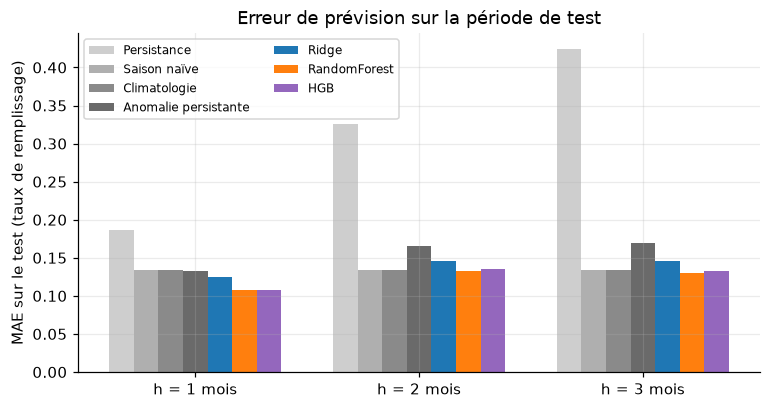

In [111]:
fig, ax = plt.subplots(figsize=(8, 4))
w = 0.11
for i, name in enumerate(order):
    vals = test_scores[test_scores["modèle"] == name].set_index("h")["MAE"].reindex(HORIZONS)
    ax.bar(np.array(HORIZONS) + (i - 3) * w, vals, width=w, label=name,
           color=plt.cm.Greys(0.3 + 0.12 * i) if i < 4 else [C_S2, "#ff7f0e", C_MODEL][i - 4])
ax.set_xticks(HORIZONS, [f"h = {h} mois" for h in HORIZONS])
ax.set_ylabel("MAE sur le test (taux de remplissage)")
ax.set_title("Erreur de prévision sur la période de test")
ax.legend(ncol=2, fontsize=8)
savefig(fig, "fig11_test_mae")
plt.show()

🤖 **Significativité.** La différence d'erreur entre le meilleur modèle et la **meilleure référence** est-elle robuste ou due à quelques mois ? Test de **Diebold-Mariano** simplifié par *bootstrap par blocs* : on rééchantillonne des **mois cibles entiers** (toutes les erreurs d'un même mois restent ensemble, ce qui respecte la corrélation spatiale entre réservoirs).

In [112]:
BEST_KIND = (
    test_scores[test_scores["modèle"].isin(GRID)]
    .groupby("modèle")["MAE"].mean().idxmin()
)
print(f"Meilleur modèle (MAE moyenne sur les horizons) : {BEST_KIND}")


def block_bootstrap_gain(df, pred_a, pred_b, n_boot=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    e = pd.DataFrame({"m": df["target_date"].values,
                      "d": np.abs(df["y"].values - pred_b) - np.abs(df["y"].values - pred_a)})
    by_month = e.groupby("m")["d"].agg(["sum", "count"])
    idx = rng.integers(0, len(by_month), size=(n_boot, len(by_month)))
    s, c = by_month["sum"].values[idx].sum(1), by_month["count"].values[idx].sum(1)
    gains = s / c
    return e["d"].mean(), np.percentile(gains, [2.5, 97.5]), (gains <= 0).mean()


rows = []
for h, df in sets.items():
    te = df[df.split == "test"]
    g, ci, p = block_bootstrap_gain(te, test_preds[h][BEST_KIND], test_preds[h][BEST_BASELINE[h]])
    rows.append({"h": h, "référence": BEST_BASELINE[h], "gain_MAE": g, "IC95_bas": ci[0], "IC95_haut": ci[1], "p_bootstrap": p})
significance = pd.DataFrame(rows)
significance.round(4)

Meilleur modèle (MAE moyenne sur les horizons) : RandomForest


,h,référence,gain_MAE,IC95_bas,IC95_haut,p_bootstrap
0,1,Climatologie,0.0262,0.0161,0.0359,0.000
1,2,Climatologie,0.0012,-0.0158,0.0140,0.407
2,3,Climatologie,0.0045,-0.0026,0.0105,0.105


💧🤖 *Interprétation attendue :* le gain doit être net à 1 mois (l'état actuel et sa dynamique récente sont très informatifs), puis s'amenuiser à 2-3 mois, où l'évolution dépend surtout des **pluies futures**, inconnues au moment de la prévision. Un modèle qui ne fait « que » égaler la climatologie à 2-3 mois n'est pas un échec : c'est la limite de prévisibilité sans prévision météorologique saisonnière.

### 10.5 Où le modèle se trompe-t-il ?

💧 On s'attend à ce que l'erreur soit maximale au **début de la saison des pluies** (juillet-août) : le remplissage dépend des pluies **futures**, inconnues au moment de la prévision. En saison sèche, la récession est régulière et prévisible.

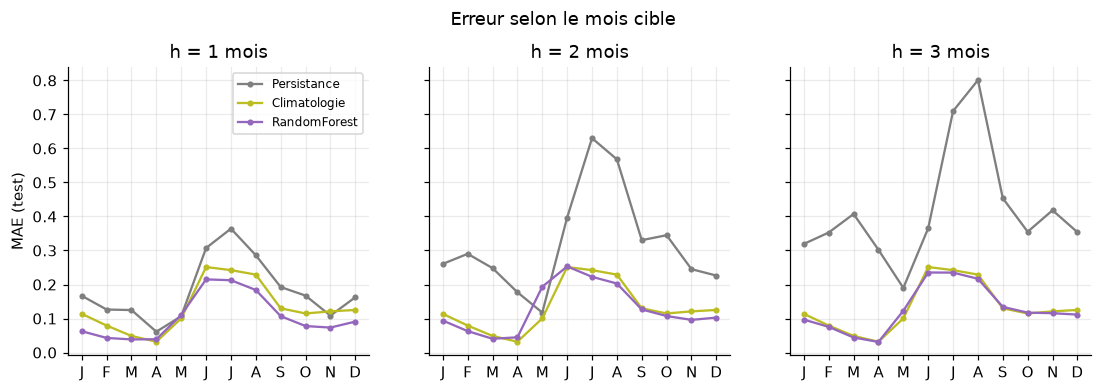

In [113]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(12, 3.4), sharey=True)
for ax, h in zip(axes, HORIZONS):
    te = sets[h][sets[h].split == "test"]
    for name, color in [("Persistance", C_REF), ("Climatologie", "#bcbd22"), (BEST_KIND, C_MODEL)]:
        err = pd.Series(np.abs(te["y"].values - test_preds[h][name]), index=te["target_month"].values)
        ax.plot(err.groupby(level=0).mean().reindex(range(1, 13)), "-o", ms=3, label=name, color=color)
    ax.set_xticks(range(1, 13), list("JFMAMJJASOND"))
    ax.set_title(f"h = {h} mois")
axes[0].set_ylabel("MAE (test)")
axes[0].legend(fontsize=8)
fig.suptitle("Erreur selon le mois cible", y=1.03)
savefig(fig, "fig12_error_by_month")
plt.show()

In [114]:
# Erreur selon la taille du réservoir (h = 1)
te = sets[1][sets[1].split == "test"].copy()
te["abs_err"] = np.abs(te["y"] - test_preds[1][BEST_KIND])
te["taille"] = pd.qcut(10 ** te["log_a_ref"], 3, labels=["petits", "moyens", "grands"])
te.groupby("taille", observed=True)["abs_err"].agg(["mean", "median", "count"]).round(3)

,mean,median,count
taille,,,
petits,0.122,0.060,640
moyens,0.103,0.058,640
grands,0.100,0.057,640


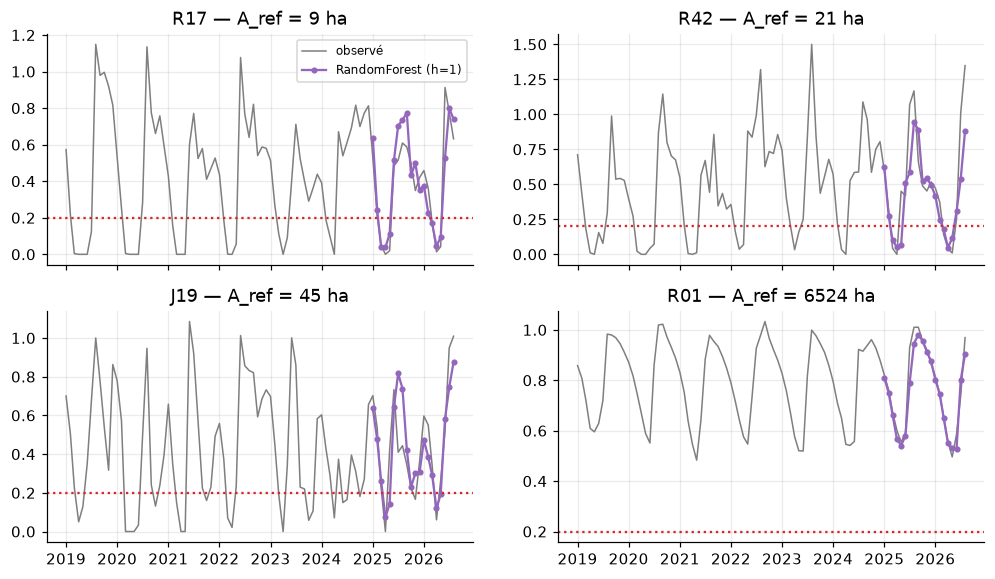

In [115]:
# Trajectoires observées vs prévues (h = 1) pour quatre réservoirs de tailles différentes
te = sets[1][sets[1].split == "test"].assign(pred=test_preds[1][BEST_KIND])
examples = static["log_a_ref"].sort_values().iloc[np.linspace(0, len(static) - 1, 4).astype(int)].index
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for ax, rid in zip(axes.flat, examples):
    hist = data[data.reservoir_id == rid]
    ax.plot(hist["date"], hist["fill"], color=C_REF, lw=1, label="observé")
    t = te[te.reservoir_id == rid]
    ax.plot(t["target_date"], t["pred"], "o-", ms=3, color=C_MODEL, label=f"{BEST_KIND} (h=1)")
    ax.axhline(CRITICAL_FILL, ls=":", color=C_S1)
    ax.set_title(f"{rid} — A_ref = {10 ** static.loc[rid, 'log_a_ref']:.0f} ha")
axes[0, 0].legend(fontsize=8)
for ax in axes[1]:
    ax.xaxis.set_major_locator(mdates.YearLocator())
savefig(fig, "fig13_examples")
plt.show()

### 10.6 Que vaudrait une prévision saisonnière des pluies ? (expérience « oracle »)

💧🤖 La principale limite du modèle est de ne pas connaître les **pluies futures**. Avant d'investir dans l'intégration de prévisions saisonnières (ECMWF SEAS5, PRESASS), on mesure le **gain maximal possible** : on fournit au modèle le cumul de pluie **réellement observé** entre *t + 1* et *t + h* (prévision parfaite).

⚠️ Ce modèle « oracle » **n'est pas déployable** (il utilise le futur). Il sert uniquement à borner la valeur d'une prévision météorologique : gain faible → inutile d'aller chercher des prévisions saisonnières ; gain fort → c'est la priorité n°1 d'amélioration.

In [116]:
def future_rain(h: int) -> pd.DataFrame:
    g = data.sort_values(["reservoir_id", "date"]).groupby("reservoir_id")["precip_mm"]
    fut = sum(g.shift(-k) for k in range(1, h + 1))
    return data[["reservoir_id", "date"]].assign(precip_future=fut)


oracle_rows = []
for h, df in sets.items():
    d = df.merge(future_rain(h), on=["reservoir_id", "date"], how="left")
    trva, te = d[d.split != "test"], d[d.split == "test"]
    cfg = best_cfg[(best_cfg.h == h) & (best_cfg.kind == BEST_KIND)].iloc[0]
    feats = F.FEATURES + ["precip_future"]
    y = trva["y"] - trva["fill_l0"] if cfg["mode"] == "delta" else trva["y"]
    pred = make_model(cfg.kind, cfg.params).fit(trva[feats], y).predict(te[feats])
    pred = np.clip(pred + (te["fill_l0"].values if cfg["mode"] == "delta" else 0), 0, 1.5)
    mae_op = mean_absolute_error(te["y"], test_preds[h][BEST_KIND])
    mae_or = mean_absolute_error(te["y"], pred)
    oracle_rows.append({"h": h, "MAE_opérationnel": mae_op, "MAE_oracle_pluie": mae_or, "gain_max": 1 - mae_or / mae_op})
oracle = pd.DataFrame(oracle_rows)
oracle.round(4)

,h,MAE_opérationnel,MAE_oracle_pluie,gain_max
0,1,0.1080,0.1088,-0.0078
1,2,0.1331,0.1344,-0.0099
2,3,0.1297,0.1313,-0.0122


In [117]:
best_gain = oracle["gain_max"].max()
if best_gain < 0.05:
    print(f"Gain maximal d'une prévision de pluie PARFAITE : {best_gain:+.1%} -> négligeable.")
    print("Les pluies futures (cumul mensuel moyen sur le sous-bassin) n'expliquent pas l'erreur résiduelle :")
    print("intégrer des prévisions saisonnières n'est PAS prioritaire pour ce modèle.")
else:
    print(f"Gain maximal d'une prévision de pluie parfaite : {best_gain:+.1%} -> piste prioritaire.")

Gain maximal d'une prévision de pluie PARFAITE : -0.8% -> négligeable.
Les pluies futures (cumul mensuel moyen sur le sous-bassin) n'expliquent pas l'erreur résiduelle :
intégrer des prévisions saisonnières n'est PAS prioritaire pour ce modèle.


---
## 11. Incertitude, alerte précoce et explicabilité

### 11.1 Intervalles de prédiction (régression quantile conformalisée)

🤖 *Une prévision sans incertitude n'est pas actionnable.* On entraîne deux modèles de gradient boosting en **perte quantile** (α = 0,10 et 0,90) → intervalle nominal à 80 %. Les modèles quantiles sont souvent mal calibrés ; on applique donc une **correction conforme** (*Conformalized Quantile Regression*, Romano et al., 2019) calculée sur la validation : on élargit l'intervalle du quantile empirique des dépassements, ce qui garantit (sous hypothèse d'échangeabilité) une couverture proche de 80 %.

Métriques : **PICP** (part des observations dans l'intervalle, cible 0,80) et **MPIW** (largeur moyenne).

In [118]:
ALPHA_LO, ALPHA_HI, NOMINAL = 0.10, 0.90, 0.80


def best_hgb_params(h):
    return best_cfg[(best_cfg.h == h) & (best_cfg.kind == "HGB")]["params"].iloc[0]


def fit_quantile(h, alpha, train):
    params = {**best_hgb_params(h), "loss": "quantile", "quantile": alpha}
    model = make_model("HGB", params)
    return model.fit(train[F.FEATURES], train["y"] - train["fill_l0"])


def predict_quantile(model, df):
    return np.clip(model.predict(df[F.FEATURES]) + df["fill_l0"].values, 0, 1.5)

In [119]:
interval_rows, conformal_q = [], {}
for h, df in sets.items():
    tr, va, te = df[df.split == "train"], df[df.split == "valid"], df[df.split == "test"]
    # 1) calibration conforme : modèles entraînés sur train, scores sur valid
    q_lo, q_hi = fit_quantile(h, ALPHA_LO, tr), fit_quantile(h, ALPHA_HI, tr)
    lo, hi = predict_quantile(q_lo, va), predict_quantile(q_hi, va)
    scores = np.maximum(lo - va["y"].values, va["y"].values - hi)
    n = len(scores)
    conformal_q[h] = float(np.quantile(scores, min(1.0, np.ceil((n + 1) * NOMINAL) / n)))
    # 2) test : modèles ré-entraînés sur train+valid
    trva = df[df.split != "test"]
    q_lo, q_hi = fit_quantile(h, ALPHA_LO, trva), fit_quantile(h, ALPHA_HI, trva)
    lo, hi = predict_quantile(q_lo, te), predict_quantile(q_hi, te)
    for name, (l, u) in {"quantile brut": (lo, hi),
                         "conformalisé": (np.clip(lo - conformal_q[h], 0, 1.5), np.clip(hi + conformal_q[h], 0, 1.5))}.items():
        inside = (te["y"].values >= l) & (te["y"].values <= u)
        interval_rows.append({"h": h, "méthode": name, "PICP": inside.mean(), "MPIW": (u - l).mean()})
    test_preds[h]["lo"], test_preds[h]["hi"] = np.clip(lo - conformal_q[h], 0, 1.5), np.clip(hi + conformal_q[h], 0, 1.5)
pd.DataFrame(interval_rows).round(3)

,h,méthode,PICP,MPIW
0,1,quantile brut,0.702,0.274
1,1,conformalisé,0.834,0.333
2,2,quantile brut,0.680,0.365
3,2,conformalisé,0.802,0.402
4,3,quantile brut,0.697,0.394
5,3,conformalisé,0.749,0.403


### 11.2 Alerte précoce de niveau critique (Q4)

🤖 Classifieur `HistGradientBoostingClassifier` (mêmes variables, classes pondérées car l'événement est minoritaire), comparé à deux règles :
- **persistance** : alerte si le réservoir est déjà sous le seuil ;
- **régression** : alerte si la prévision du meilleur régresseur est sous le seuil.

Métriques probabilistes : **ROC-AUC**, **PR-AUC** (précision moyenne, plus informative pour un événement rare), **score de Brier**. Pour une décision binaire, le seuil de probabilité est choisi sur la **validation** (maximisation du F1), puis appliqué tel quel au test.

In [120]:
def make_classifier():
    return HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=30,
        l2_regularization=1.0, class_weight="balanced", random_state=SEED,
    )


def best_f1_threshold(y, proba):
    grid = np.linspace(0.05, 0.95, 91)
    f1s = [f1_score(y, proba >= t, zero_division=0) for t in grid]
    return float(grid[int(np.argmax(f1s))])

In [121]:
alert_rows, alert_thresholds, alert_proba = [], {}, {}
for h, df in sets.items():
    tr, va, te = df[df.split == "train"], df[df.split == "valid"], df[df.split == "test"]
    ev = lambda d: (d["y"] < CRITICAL_FILL).astype(int)
    clf = make_classifier().fit(tr[F.FEATURES], ev(tr))
    alert_thresholds[h] = best_f1_threshold(ev(va), clf.predict_proba(va[F.FEATURES])[:, 1])
    clf = make_classifier().fit(df[df.split != "test"][F.FEATURES], ev(df[df.split != "test"]))
    proba = clf.predict_proba(te[F.FEATURES])[:, 1]
    alert_proba[h] = proba
    y_te = ev(te)
    candidates = {
        "Persistance": (te["fill_l0"] < CRITICAL_FILL).astype(float).values,
        f"Régression {BEST_KIND}": (test_preds[h][BEST_KIND] < CRITICAL_FILL).astype(float),
        "Classifieur HGB": proba,
    }
    for name, score in candidates.items():
        binary = score >= (alert_thresholds[h] if name == "Classifieur HGB" else 0.5)
        alert_rows.append({
            "h": h, "méthode": name,
            "ROC-AUC": roc_auc_score(y_te, score) if name == "Classifieur HGB" else np.nan,
            "PR-AUC": average_precision_score(y_te, score) if name == "Classifieur HGB" else np.nan,
            "Brier": brier_score_loss(y_te, score) if name == "Classifieur HGB" else np.nan,
            "Précision": precision_score(y_te, binary, zero_division=0),
            "Rappel": recall_score(y_te, binary, zero_division=0),
            "F1": f1_score(y_te, binary, zero_division=0),
            "taux_événement": y_te.mean(),
        })
alert_scores = pd.DataFrame(alert_rows)
alert_scores.round(3)

,h,méthode,ROC-AUC,PR-AUC,Brier,Précision,Rappel,F1,taux_événement
0,1,Persistance,NaN,NaN,NaN,0.764,0.774,0.769,0.404
1,1,Régression RandomForest,NaN,NaN,NaN,0.923,0.846,0.883,0.404
2,1,Classifieur HGB,0.969,0.953,0.069,0.872,0.899,0.886,0.404
3,2,Persistance,NaN,NaN,NaN,0.564,0.572,0.568,0.404
4,2,Régression RandomForest,NaN,NaN,NaN,0.924,0.724,0.812,0.404
5,2,Classifieur HGB,0.957,0.942,0.084,0.886,0.786,0.833,0.404
6,3,Persistance,NaN,NaN,NaN,0.400,0.396,0.398,0.404
7,3,Régression RandomForest,NaN,NaN,NaN,0.900,0.810,0.853,0.404
8,3,Classifieur HGB,0.958,0.941,0.080,0.903,0.808,0.853,0.404


💧 *Lecture opérationnelle :* l'intérêt d'une alerte ne se mesure pas sur les réservoirs **déjà** critiques (la persistance les détecte trivialement) mais sur les **entrées en crise** : réservoirs au-dessus du seuil aujourd'hui et en dessous dans *h* mois. C'est la vraie valeur ajoutée d'un système d'alerte précoce.

In [122]:
rows = []
for h, df in sets.items():
    te = df[df.split == "test"]
    onset = (te["fill_l0"] >= CRITICAL_FILL).values
    y_on = (te["y"].values < CRITICAL_FILL)[onset]
    if y_on.sum() == 0:
        continue
    p_on = alert_proba[h][onset]
    pred_on = p_on >= alert_thresholds[h]
    rows.append({"h": h, "n_situations": onset.sum(), "n_entrées_en_crise": int(y_on.sum()),
                 "détectées": int((pred_on & y_on).sum()),
                 "fausses_alertes": int((pred_on & ~y_on).sum()),
                 "ROC-AUC": roc_auc_score(y_on, p_on) if 0 < y_on.mean() < 1 else np.nan})
pd.DataFrame(rows).round(3)

,h,n_situations,n_entrées_en_crise,détectées,fausses_alertes,ROC-AUC
0,1,1135,175,123,25,0.966
1,2,1134,332,256,36,0.961
2,3,1153,468,374,40,0.959


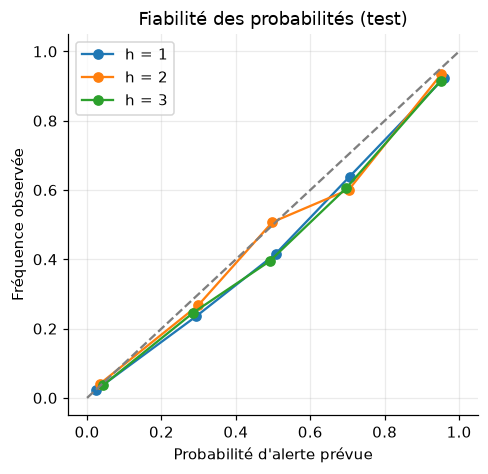

In [123]:
# Diagramme de fiabilité (calibration des probabilités d'alerte)
fig, ax = plt.subplots(figsize=(4.8, 4.5))
for h in HORIZONS:
    te = sets[h][sets[h].split == "test"]
    y = (te["y"] < CRITICAL_FILL).astype(int).values
    bins = pd.cut(alert_proba[h], np.linspace(0, 1, 6), include_lowest=True)
    rel = pd.DataFrame({"p": alert_proba[h], "y": y, "b": bins}).groupby("b", observed=True).mean()
    ax.plot(rel["p"], rel["y"], "o-", label=f"h = {h}")
ax.plot([0, 1], [0, 1], "--", color=C_REF)
ax.set_xlabel("Probabilité d'alerte prévue")
ax.set_ylabel("Fréquence observée")
ax.set_title("Fiabilité des probabilités (test)")
ax.legend()
savefig(fig, "fig14_reliability")
plt.show()

🤖 *Faut-il recalibrer les probabilités ?* La pondération des classes (`class_weight="balanced"`) peut déformer les probabilités ; une **régression isotonique** peut les corriger, mais avec une seule année de validation elle risque aussi de sur-apprendre et de les **dégrader**. On ne tranche donc pas a priori : on calibre sur la première moitié des mois de validation, on compare le score de Brier brut et recalibré sur la seconde moitié, et on ne garde la calibration que si elle améliore. Le test n'intervient pas dans ce choix ; il sert seulement à vérifier la décision.

In [124]:
from sklearn.isotonic import IsotonicRegression

calibrators, rows = {}, []
for h, df in sets.items():
    tr, va, te = df[df.split == "train"], df[df.split == "valid"], df[df.split == "test"]
    ev = lambda d: (d["y"] < CRITICAL_FILL).astype(int)
    p_va = make_classifier().fit(tr[F.FEATURES], ev(tr)).predict_proba(va[F.FEATURES])[:, 1]
    # Décision sur la validation seule : calibrer sur ses premiers mois, juger sur les suivants
    months = np.sort(va["target_date"].unique())
    first = va["target_date"].isin(months[: len(months) // 2]).values
    iso = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1).fit(p_va[first], ev(va)[first])
    brier_raw_va = brier_score_loss(ev(va)[~first], p_va[~first])
    brier_cal_va = brier_score_loss(ev(va)[~first], iso.predict(p_va[~first]))
    use = brier_cal_va < brier_raw_va
    # Si retenue, la calibration est réapprise sur toute la validation
    calibrators[h] = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1).fit(p_va, ev(va)) if use else None
    p_cal = calibrators[h].predict(alert_proba[h]) if use else alert_proba[h]
    rows.append({"h": h, "Brier valid. brut": brier_raw_va, "Brier valid. calibré": brier_cal_va,
                 "calibration retenue": use,
                 "Brier test brut": brier_score_loss(ev(te), alert_proba[h]),
                 "Brier test servi": brier_score_loss(ev(te), p_cal)})
calibration_table = pd.DataFrame(rows)
calibration_table.round(4)

,h,Brier valid. brut,Brier valid. calibré,calibration retenue,Brier test brut,Brier test servi
0,1,0.0450,0.0466,False,0.0688,0.0688
1,2,0.0463,0.0482,False,0.0837,0.0837
2,3,0.0483,0.0494,False,0.0801,0.0801


### 11.3 Explicabilité

🤖 **Importance par permutation** sur le test : baisse de performance quand on mélange une variable. Contrairement à l'importance « impureté » des arbres (biaisée vers les variables continues à nombreuses valeurs), elle est mesurée sur des données non vues et comparable entre modèles.

💧 *Ce qu'on attend physiquement :* l'état actuel (`fill_l0`) et la climatologie du mois cible doivent dominer ; les pluies récentes et l'humidité du sol doivent compter surtout en début de saison des pluies.

In [125]:
imp = {}
for h in (1, 3):
    model, mode = fitted[(h, BEST_KIND)]
    te = sets[h][sets[h].split == "test"]
    y_eval = te["y"] - te["fill_l0"] if mode == "delta" else te["y"]
    r = permutation_importance(model, te[F.FEATURES], y_eval, n_repeats=10, random_state=SEED,
                               scoring="neg_mean_absolute_error", n_jobs=N_JOBS)
    imp[h] = pd.Series(r.importances_mean, index=F.FEATURES)
imp = pd.DataFrame(imp).add_prefix("h=")
top = imp.sort_values("h=1", ascending=False).head(15)
top.round(4)

,h=1,h=3
fill_l0,0.0928,0.0053
clim_target,0.0805,0.1383
precip_mm,0.0262,0.0191
clim_precip_target,0.0179,0.0190
dfill_1,0.0090,0.0011
anom_issue,0.0087,0.0032
precip_3m,0.0061,0.0031
clim_issue,0.0054,0.0020
issue_month_cos,0.0033,0.0066
jrc_seasonality,0.0029,0.0060


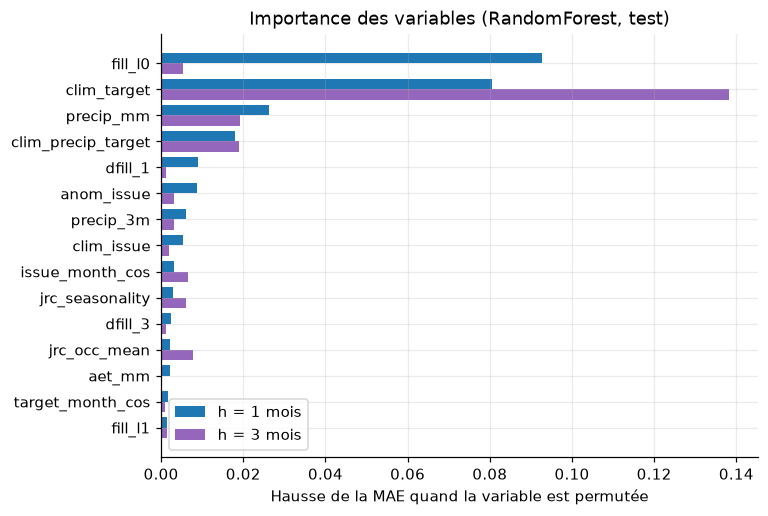

In [126]:
fig, ax = plt.subplots(figsize=(7, 5))
y = np.arange(len(top))
ax.barh(y - 0.2, top["h=1"], height=0.4, label="h = 1 mois", color=C_S2)
ax.barh(y + 0.2, top["h=3"], height=0.4, label="h = 3 mois", color=C_MODEL)
ax.set_yticks(y, top.index)
ax.invert_yaxis()
ax.set_xlabel("Hausse de la MAE quand la variable est permutée")
ax.set_title(f"Importance des variables ({BEST_KIND}, test)")
ax.legend()
savefig(fig, "fig15_importance")
plt.show()

---
## 12. Généralisation spatiale

🗺️🤖 *Le modèle fonctionnerait-il sur un réservoir qu'il n'a jamais vu ?* C'est la question clé pour étendre WaterTracker à d'autres bassins. Validation croisée **groupée par réservoir** (5 plis) sur les mois cibles ≤ 2024 : les réservoirs du pli de test sont totalement absents de l'entraînement.

*Nuance :* la climatologie et `A_ref` d'un réservoir « nouveau » restent calculables à partir de son propre historique satellite (disponible partout depuis 2019) ; c'est la **dynamique apprise** qu'on teste ici.

In [127]:
gkf = GroupKFold(n_splits=5)
rows = []
for h, df in sets.items():
    d = df[df.split != "test"].reset_index(drop=True)
    cfg = best_cfg[(best_cfg.h == h) & (best_cfg.kind == BEST_KIND)].iloc[0]
    for fold, (itr, ite) in enumerate(gkf.split(d, groups=d["reservoir_id"])):
        tr, te = d.iloc[itr], d.iloc[ite]
        _, pred = fit_predict(cfg.kind, cfg.params, cfg["mode"], tr, te)
        rows.append({"h": h, "pli": fold, "MAE_modèle": mean_absolute_error(te["y"], pred),
                     "MAE_persistance": mean_absolute_error(te["y"], te["fill_l0"]),
                     "MAE_climatologie": mean_absolute_error(te["y"], te["clim_target"].fillna(te["fill_l0"]))})
spatial = pd.DataFrame(rows)
spatial.groupby("h")[["MAE_modèle", "MAE_persistance", "MAE_climatologie"]].agg(["mean", "std"]).round(3)

MAE_modèle        MAE_persistance        MAE_climatologie       
        mean    std            mean    std             mean    std
h                                                                 
1      0.106  0.006           0.172  0.007            0.147  0.011
2      0.130  0.009           0.291  0.012            0.148  0.011
3      0.136  0.011           0.382  0.016            0.149  0.011

---
## 13. Modèle final, sauvegarde et inférence

### 13.1 Entraînement final

🤖 Pour la mise en production, on ré-entraîne la configuration retenue sur **toutes les données disponibles** (2019 → dernier mois) : les performances publiées sont celles du test (§10.4), le modèle déployé bénéficie des données les plus récentes. Les statistiques dépendant de la période (A_ref, climatologies) sont **conservées telles qu'apprises sur l'entraînement** pour rester cohérentes avec l'évaluation.

Pour chaque horizon, le paquet contient :
- le régresseur médian (`Pipeline`) et sa formulation (`level`/`delta`) ;
- les deux régresseurs quantiles + la correction conforme ;
- le classifieur d'alerte, son calibrateur isotonique et le seuil de décision.

In [128]:
bundle_models = {}
for h, df in sets.items():
    cfg = best_cfg[(best_cfg.h == h) & (best_cfg.kind == BEST_KIND)].iloc[0]
    y_fit = df["y"] - df["fill_l0"] if cfg["mode"] == "delta" else df["y"]
    ev = (df["y"] < CRITICAL_FILL).astype(int)
    bundle_models[h] = {
        "median": make_model(cfg.kind, cfg.params).fit(df[F.FEATURES], y_fit),
        "target_mode": cfg["mode"],
        "q_lo": fit_quantile(h, ALPHA_LO, df),
        "q_hi": fit_quantile(h, ALPHA_HI, df),
        "conformal_q": conformal_q[h],
        "classifier": make_classifier().fit(df[F.FEATURES], ev),
        "calibrator": calibrators[h],
        "alert_threshold": alert_thresholds[h],
    }
print("Modèles finaux entraînés pour h =", list(bundle_models))

Modèles finaux entraînés pour h = [1, 2, 3]


### 13.2 Sauvegarde

💻 Arborescence (compatible avec `ml/runs/` de l'API, sans écraser le modèle v2 dans `ml/runs/latest`) :

```
ml/runs/forecast_<horodatage>/
├── bundle.joblib        # modèles + statistiques nécessaires à l'inférence
├── model_card.json      # fiche du modèle : données, protocole, métriques, limites
└── test_scores.csv      # tableau des performances (test)
ml/runs/forecast_latest/  # copie du dernier run (chargée par l'API)
```

La **fiche du modèle** (*model card*, Mitchell et al., 2019) documente les données, le protocole, les performances et les limites d'usage.

In [129]:
import shutil
import subprocess

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = RUNS_DIR / f"forecast_{run_id}"
run_dir.mkdir(parents=True, exist_ok=True)

try:
    git_commit = subprocess.run(["git", "rev-parse", "--short", "HEAD"], cwd=BACKEND_DIR,
                                capture_output=True, text=True, check=True).stdout.strip()
except Exception:
    git_commit = None

bundle = {
    "version": "3.0",
    "created": datetime.now().isoformat(timespec="seconds"),
    "features": F.FEATURES,
    "horizons": HORIZONS,
    "critical_fill": CRITICAL_FILL,
    "train_end": TRAIN_END,
    "models": bundle_models,
    "climatology": climatology,
    "static": static,
    "a_ref_ha": res.set_index("reservoir_id")["a_ref_ha"],
    "reservoir_sources": res.set_index("reservoir_id")["source_ids"],
    "s1_mapping": s1_map,
    "s1_column": S1_COL,
}
joblib.dump(bundle, run_dir / "bundle.joblib", compress=3)
print(f"Paquet sauvegardé : {run_dir / 'bundle.joblib'} ({(run_dir / 'bundle.joblib').stat().st_size / 1e6:.1f} Mo)")

Paquet sauvegardé : D:\Dossiers\WaterTracker_Project\backend\ml\runs\forecast_20261008_095246\bundle.joblib (44.6 Mo)


In [130]:
best_test = test_scores[test_scores["modèle"] == BEST_KIND].set_index("h")
model_card = {
    "nom": "WaterTracker — prévision du taux de remplissage des réservoirs",
    "version": "3.0",
    "run_id": run_id,
    "git_commit": git_commit,
    "usage_prévu": "Aide à la décision : anticiper à 1-3 mois l'état des réservoirs autour de Ouagadougou.",
    "usage_non_prévu": "Estimation de volumes (pas de bathymétrie) ; réservoirs hors zone sans revalidation.",
    "données": {
        "zone": {"centre": [center_lat, center_lng], "rayon_m": settings.watch_radius_m},
        "période": [START_MONTH, END_MONTH],
        "réservoirs_modélisés": int(res["modelable"].sum()),
        "réservoirs_par_origine": res.loc[res["modelable"], "origin"].value_counts().to_dict(),
        "sources_application": int(len(src)),
        "résolution_m": SCALE_M,
        "capteurs": ["Sentinel-2 SR (MNDWI>0 affiné à 10 m, Cloud Score+ >= 0.6)", f"Sentinel-1 VV < {best_thr} dB (comblement)",
                     "CHIRPS daily", "ERA5-Land monthly", "JRC GSW 1.4", "SRTM", "HydroBASINS lvl 10"],
        "empreinte_panel": DATA_HASH,
    },
    "cible": f"taux de remplissage fill = surface / A_ref (P95 entraînement), seuil critique {CRITICAL_FILL}",
    "protocole": {"train": f"<= {TRAIN_END}", "validation": f"<= {VALID_END}", "test": f"> {VALID_END}",
                  "spatial": "GroupKFold(5) par réservoir"},
    "modèle": {"famille": BEST_KIND,
               "configs": {int(h): {"mode": c["mode"], "params": c["params"]}
                           for h, c in best_cfg[best_cfg.kind == BEST_KIND].set_index("h").iterrows()}},
    "performances_test": {
        int(h): {
            "MAE": round(float(best_test.loc[h, "MAE"]), 4),
            "NSE": round(float(best_test.loc[h, "NSE"]), 4),
            "KGE": round(float(best_test.loc[h, "KGE"]), 4),
            "référence": BEST_BASELINE[h],
            "skill_vs_reference": round(float(best_test.loc[h, "Skill_vs_reference"]), 4),
            "p_bootstrap_vs_reference": round(float(significance.set_index("h").loc[h, "p_bootstrap"]), 4),
            "PICP_80": round(float(pd.DataFrame(interval_rows).query("h == @h and méthode == 'conformalisé'")["PICP"].iloc[0]), 3),
        } for h in HORIZONS
    },
    "gain_max_prévision_pluie_parfaite": {int(r.h): round(float(r.gain_max), 4) for r in oracle.itertuples()},
    "versions": versions,
    "limites": [
        "Surface en eau ; volume seulement indicatif (Liebe et al. 2005, valide de 1 à 35 ha).",
        "Pluies futures inconnues : erreur maximale en début de saison des pluies.",
        f"Inventaire de l'application : {len(src)} sources pour {int((res.origin == 'application').sum())} plans d'eau physiques ; "
        f"{len(added)} plans d'eau JRC >= {JRC_MIN_HA} ha absents de l'application ont été ajoutés.",
        "Sentinel-1 en orbite ascendante seule depuis la perte de S1B (déc. 2021).",
    ],
}
(run_dir / "model_card.json").write_text(json.dumps(model_card, ensure_ascii=False, indent=2), encoding="utf-8")
table.to_csv(run_dir / "test_scores.csv")

In [131]:
latest = RUNS_DIR / "forecast_latest"
if latest.exists():
    shutil.rmtree(latest)
shutil.copytree(run_dir, latest)
sorted(p.name for p in latest.iterdir())

['bundle.joblib', 'model_card.json', 'test_scores.csv']

### 13.3 Vérification du rechargement

💻 Un modèle sauvegardé qu'on ne sait pas recharger ne vaut rien. On recharge le paquet **depuis le disque** et on vérifie que les prédictions sont identiques à celles du modèle en mémoire.

In [132]:
reloaded = joblib.load(latest / "bundle.joblib")
df_chk = sets[1].tail(50)
same = np.allclose(
    reloaded["models"][1]["median"].predict(df_chk[reloaded["features"]]),
    bundle_models[1]["median"].predict(df_chk[F.FEATURES]),
)
print("Rechargement identique :", same)
assert same

Rechargement identique : True


### 13.4 Prévision opérationnelle

On émet maintenant la prévision réelle à partir du **dernier mois observé**, pour chaque réservoir et chaque horizon, avec l'intervalle à 80 % et la probabilité calibrée d'atteindre le niveau critique.

💻 La fonction `forecast` vient de `ml/forecasting.py` : c'est **exactement** celle qu'exécute l'API chaque mois.

Correspondance avec les statuts de l'application :
- **tari** : remplissage prévu < 5 % ;
- **à risque** : probabilité calibrée de niveau critique ≥ 50 % ;
- **actif** : sinon.

In [133]:
# Même fonction que celle utilisée par l'API pour ses mises à jour mensuelles (ml/forecasting.py)
from ml.forecasting import forecast

fc = forecast(reloaded, data)
fc.head(9).round(3)

,reservoir_id,issue_month,horizon,target_month,fill_now,fill_pred,fill_lo80,fill_hi80,p_critical,status
0,J01,2026-08,1,2026-09,0.985,0.855,0.211,1.151,0.280,actif
1,J02,2026-08,1,2026-09,1.140,0.876,0.812,1.098,0.001,actif
2,J03,2026-08,1,2026-09,0.044,0.237,0.009,0.510,0.903,à risque
3,J04,2026-08,1,2026-09,1.200,0.876,0.835,1.205,0.001,actif
4,J05,2026-08,1,2026-09,0.464,0.694,0.285,0.896,0.017,actif
5,J06,2026-08,1,2026-09,0.748,0.679,0.536,0.824,0.003,actif
6,J07,2026-08,1,2026-09,1.060,0.960,0.812,1.072,0.001,actif
7,J08,2026-08,1,2026-09,0.490,0.814,0.451,0.929,0.003,actif
8,J10,2026-08,1,2026-09,0.984,0.743,0.650,1.025,0.001,actif


In [134]:
fc.pivot_table(index="status", columns="horizon", values="reservoir_id", aggfunc="count", fill_value=0)

horizon,1,2,3
status,,,
actif,94,86,84
tari,0,0,1
à risque,2,10,11


In [135]:
# Export pour l'application : une ligne par source (les sources d'un même réservoir partagent la prévision)
app_res = res.loc[res["origin"] == "application", ["reservoir_id", "source_ids", "a_ref_ha"]]
fc_src = fc.merge(app_res, on="reservoir_id").explode("source_ids")
fc_src = fc_src.rename(columns={"source_ids": "source_id"})
fc_src["area_pred_ha"] = fc_src["fill_pred"] * fc_src["a_ref_ha"]
# Volume indicatif (Liebe et al., 2005), uniquement dans le domaine de validité de la relation
in_range = fc_src["a_ref_ha"].between(*LIEBE_RANGE_HA)
fc_src["volume_pred_m3"] = np.where(in_range, area_to_volume_m3(fc_src["area_pred_ha"]), np.nan)
fc_src.to_csv(DATA_DIR / "forecast_latest.csv", index=False)
print(f"{len(fc_src)} lignes exportées -> {DATA_DIR / 'forecast_latest.csv'}")

189 lignes exportées -> D:\Dossiers\WaterTracker_Project\backend\data\gee\forecast_latest.csv


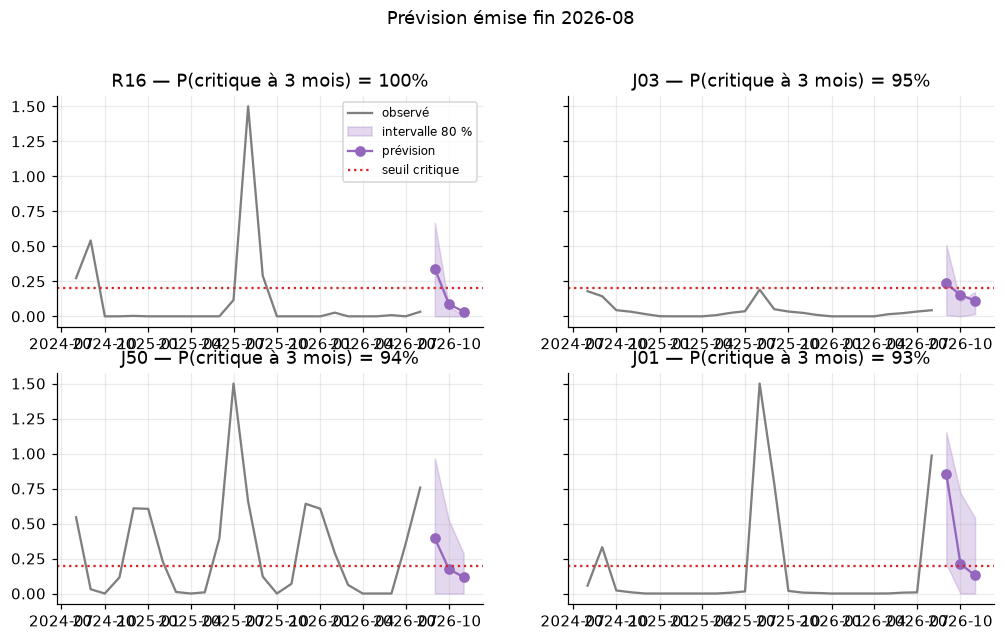

In [136]:
# Éventail de prévision pour les quatre réservoirs les plus menacés à 3 mois
worst = fc[fc.horizon == 3].nlargest(4, "p_critical")["reservoir_id"]
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharey=True)
for ax, rid in zip(axes.flat, worst):
    hist = data[(data.reservoir_id == rid) & (data.date >= data.date.max() - pd.DateOffset(months=24))]
    f = fc[fc.reservoir_id == rid]
    t = pd.to_datetime(f["target_month"])
    ax.plot(hist["date"], hist["fill"], color=C_REF, label="observé")
    ax.fill_between(t, f["fill_lo80"], f["fill_hi80"], color=C_MODEL, alpha=0.25, label="intervalle 80 %")
    ax.plot(t, f["fill_pred"], "o-", color=C_MODEL, label="prévision")
    ax.axhline(CRITICAL_FILL, ls=":", color=C_S1, label="seuil critique")
    p3 = f.loc[f.horizon == 3, "p_critical"].iloc[0]
    ax.set_title(f"{rid} — P(critique à 3 mois) = {p3:.0%}")
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"Prévision émise fin {fc['issue_month'].iloc[0]}", y=1.01)
savefig(fig, "fig16_forecast_fan")
plt.show()

---
## 14. Limites, réponses apportées et perspectives

### 14.1 Limites : ce qui est comblé ici, ce qui reste à faire

| Limite | Réponse apportée dans ce notebook | Ce qu'il faudrait pour la lever complètement |
|---|---|---|
| 📐 Résolution spatiale | Mesure à **10 m** : MNDWI avec SWIR affiné (Du et al., 2016), contrôle par NDWI natif 10 m, effet 10 m / 20 m quantifié (§4.6) | Imagerie métrique (PlanetScope 3 m, Pléiades) pour les mares < 1 ha |
| 💧 Surface et non volume | Volume estimé par la relation régionale de Liebe et al. (2005), avec domaine de validité explicite (§4.7) | Bathymétrie des grands barrages (DGRE/ONEA), altimétrie **SWOT** ou ICESat-2 pour une courbe hauteur-surface-volume par réservoir |
| 🌧️ Pluies futures inconnues | Climatologie de la pluie du mois cible en variable ; **expérience oracle** bornant le gain d'une prévision parfaite (§10.6) | Prévisions saisonnières **ECMWF SEAS5** (Copernicus C3S) ou PRESASS/AGRHYMET en variables du modèle |
| ☁️ Nuages en saison des pluies | Masque pixel Cloud Score+, composite mensuel, comblement **Sentinel-1** calibré et validé (§4.3) | Fusion bayésienne S1/S2 ; Sentinel-1C (lancé fin 2024) pour doubler la revisite radar |
| 🗺️ Inventaire incomplet et doublonné | Dédoublonnage, contrôle de complétude contre JRC, **inventaire étendu** (§2.1) | Détection automatique annuelle à 10 m ; validation terrain et toponymie (base nationale des retenues) |
| 🗺️ Bassin versant approximatif | Sous-bassin HydroBASINS niveau 10 + surface amont (`UP_AREA`) en variable | Délimitation du bassin à l'exutoire de chaque barrage sur MNT (MERIT Hydro, 90 m) |
| 🛰️ Seuil d'eau fixe | Analyse de sensibilité au seuil ±0,1 (§4.5) | Seuillage adaptatif (Otsu) par scène et par réservoir |
| 🌿 Végétation aquatique | Non traitée ; le radar atténue partiellement l'effet | Classification eau libre / eau végétalisée (indices red-edge B5-B7, polarisation VH) |
| 🤖 Historique court (≈ 5 cycles en entraînement) | Références climatologiques fortes, incertitude conforme, généralisation spatiale testée (§12) | Prolonger avec Landsat (30 m, depuis 1984) pour la climatologie longue et les années extrêmes |
| 💧 Prélèvements et lâchers non observés | Absorbés implicitement dans la récession apprise | Données d'exploitation (ONEA, périmètres irrigués) ou estimation par bilan hydrique |
| ✅ Pas de vérité terrain | Cohérence inter-capteurs S1/S2, cohérence avec JRC | Échelles limnimétriques, relevés GPS de berges à dates de passage satellite |

💧 **Autres points de vigilance**
- Pour les cuvettes très plates, une faible baisse de niveau entraîne une forte baisse de surface : le taux de remplissage en surface n'est pas linéaire avec le stock (voir §4.7).
- Les réservoirs ne sont pas indépendants (même climat) : la validation temporelle reste la plus honnête, mais le nombre d'années de test est faible.

### 14.2 Feuille de route recommandée
1. **Prévisions saisonnières** de pluie : seulement si l'expérience oracle (§10.6) montre un gain substantiel à 2-3 mois. Si le gain est nul, l'effort doit porter ailleurs (volume, validation terrain, qualité de l'inventaire).
2. **Volume** : coupler à SWOT pour les grands barrages ; campagne bathymétrique légère (sondeur + GPS) sur quelques petites retenues pour recaler la relation de Liebe localement.
3. **Assimilation mensuelle** : la collecte planifiée de l'API alimente le même panel ; ré-entraînement annuel après la saison des pluies.
4. **Validation terrain** avec la DGRE / l'ONEA sur quelques barrages instrumentés.

In [137]:
# Synthèse chiffrée (générée à partir des résultats, pour le résumé de l'article)
b = test_scores[test_scores["modèle"] == BEST_KIND].set_index("h")
picp = pd.DataFrame(interval_rows).query("méthode == 'conformalisé'").set_index("h")["PICP"]
n_app = int((res.origin == "application").sum())
print(f"Inventaire : {len(src)} sources -> {n_app} réservoirs physiques ; + {len(added)} ajoutés (JRC) ; "
      f"{res['modelable'].sum()} modélisés")
print(f"Panel : {data.reservoir_id.nunique()} réservoirs x {data.month.nunique()} mois ; "
      f"provenance : {dict(data['area_source'].value_counts(normalize=True).round(3))}")
for h in HORIZONS:
    print(f"h={h} : MAE {b.loc[h, 'MAE']:.3f} ({BEST_BASELINE[h]} {ref_mae[h]:.3f}), "
          f"skill {b.loc[h, 'Skill_vs_reference']:+.1%}, NSE {b.loc[h, 'NSE']:.2f}, KGE {b.loc[h, 'KGE']:.2f}, "
          f"couverture IP80 {picp.loc[h]:.0%}")

Inventaire : 65 sources -> 44 réservoirs physiques ; + 56 ajoutés (JRC) ; 96 modélisés
Panel : 96 réservoirs x 92 mois ; provenance : {'S2': np.float64(0.987), 'S1': np.float64(0.009), 'interp': np.float64(0.005)}
h=1 : MAE 0.108 (Climatologie 0.134), skill +19.6%, NSE 0.80, KGE 0.80, couverture IP80 83%
h=2 : MAE 0.133 (Climatologie 0.134), skill +0.9%, NSE 0.74, KGE 0.74, couverture IP80 80%
h=3 : MAE 0.130 (Climatologie 0.134), skill +3.4%, NSE 0.75, KGE 0.75, couverture IP80 75%


### 14.3 Conclusion

Ce notebook remplace une chaîne fondée sur un **NDWI ponctuel semestriel** (dont le diagnostic §6 a montré la cible saisonnière, la fuite d'information et un bug d'inférence) par une chaîne **reproductible** et **physiquement fondée** :
1. un inventaire SIG contrôlé (doublons, validité, confrontation à JRC) ;
2. une **surface en eau mensuelle à 10 m** fusionnant Sentinel-2 (masquage Cloud Score+) et Sentinel-1 (calibré et validé sur données indépendantes) ;
3. une analyse hydrologique (régime, réponse aux pluies, récession, tendances avec contrôle du taux de fausses découvertes) ;
4. un modèle de prévision évalué honnêtement (validation temporelle, références fortes, test de significativité, généralisation spatiale), assorti d'**intervalles calibrés** et d'une **alerte probabiliste** ;
5. un paquet de modèle versionné, documenté (*model card*) et vérifié au rechargement, prêt à être servi par l'API.

Les chiffres de la synthèse ci-dessus constituent les résultats principaux de l'article.